# 1. Data collection and preprocessing
This repository detailed the list of processing and analysis how to retrieve a continuous diurnal LST during peak summer months with high spatial resolution.

| Data                 | Data source     | Access / Download source                                               | Preprocessing | Reference                              |
|----------------------|-----------------|------------------------------------------------------------------------|---------------|----------------------------------------|
| Daytime and Nighttime – Coarse     | MODIS           | APPEEARS - https://appeears.earthdatacloud.nasa.gov/                   | OSGeo4W Shell | [Modis_preprocessing](preprocessing/modis.txt)     |
| 		       | Himawari SST    | WinSCP - https://winscp.net/eng/download.php                           | OSGeo4W Shell | [Himawari_preprocessing](preprocessing/himawari.txt)  |
| Daytime – Fine       | Landsat 8 and 9 | Google Earth Engine - GEE code (Ermida et al., 2020) https://github.com/sofiaermida/Landsat_SMW_LST                  | GEE | [Landsat_preprocessing](preprocessing/landsat.txt)   |
| Nighttime – Fine   | ECOSTRESS       | APPEEARS - https://appeears.earthdatacloud.nasa.gov/                   | ArcGIS - Spatial analyst | Mosaic and Raster calculator to convert Kelvin into Celcius |

# 2. Data description

In [2]:
import pandas as pd
# load the list of images
image_list = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\xlsx\list_of_images_csv.csv")

# Preview first 40 rows
display(image_list.head(40))

,spatial,temporal,use,date,view_time_UTC,view_time_AEDT,file_ID
0,Fine,Daytime,Base,7/01/2023,7/01/2023 0:04,7/01/2023 11:04,LC80920862023007LGN00
1,Fine,Daytime,Reference,8/01/2021,8/01/2021 0:10,8/01/2021 11:10,LC80930862021008LGN00
2,Fine,Daytime,Reference,19/01/2022,19/01/2022 0:10,19/01/2022 11:10,LC90930862022019LGN01
3,Fine,Daytime,Reference,20/01/2022,20/01/2022 0:04,20/01/2022 11:04,LC80920872022020LGN00
4,Fine,Nighttime,Base,25/12/2022,25/12/2022 12:50,25/12/2022 23:50,ECO_L2T_LSTE.002_LST_doy2022359124954_aid0001_55S
5,Fine,Nighttime,Base,25/12/2022,25/12/2022 12:50,25/12/2022 23:50,ECO_L2T_LSTE.002_LST_doy2022359125046_aid0001_55S
6,Fine,Nighttime,Reference,12/12/2021,12/12/2021 11:22,12/12/2021 22:22,ECO_L2T_LSTE.002_LST_doy2021346112222_aid0001_55S
7,Fine,Nighttime,Reference,9/02/2023,9/02/2023 12:50,9/02/2023 23:50,ECO_L2T_LSTE.002_LST_doy2023040114723_aid0001_55S
8,Coarse,Daytime,Base,7/01/2023,6/01/2023 22:48,7/01/2023 9:48,MOD11A1.061_LST_Day_1km_doy2023007000000_aid0001
9,Coarse,Daytime,Reference,8/01/2021,7/01/2021 23:54,8/01/2021 10:54,MOD11A1.061_LST_Day_1km_doy2021008000000_aid0001


# 2. Coarse images: Mosaicking, Reprojection, Resampling
The STARFM preprocessing steps are shown below

## 2.2 Daytime
The himawari image does not fully cover the Port Philip bay. Extrapolation using IDW was conducted. The original resolution was 2km. It was resampled to 1km to fit with the MODIS data. Then the SST in the study area is extracted using this file
C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\shapefile\ppb_square_b.7z

Extraction of the MODIS using a full rectangle with width and height values multiple by 1km (Unit of MODIS)
C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\shapefile\MODIS_fishnet_diss.7z

After alignment with the reference extract the output using
C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\shapefile\MODIS_extractByMask.7z

Resampling to 30 m (Reference fine = Landasat). 
Corresponding file to get the width and height (same extent as reference image), the following file was used
C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\shapefile\modis_30m_fish_diss_e.7z

## 2.3 Nightime
Resampling to 70 m (Reference fine = ECOSTRESS).
Corresponding file to get the width and height (same extent as reference image), the following file was used
...\shapefile\modis_70m_fishnet_20230209_diss.7z

The full preprocessing workflow is available at:
- [Daytime data processing](preprocessing/daytime_preprocessing.txt)
- [Nighttime data processing](preprocessing/nighttime_preprocessing.txt)

# 3. Spatiotemporal data fusion
## 3.1. STARFM
To run STARFM, the following repository was used (Mileva et al. 2018)
https://github.com/nmileva/starfm4py?tab=readme-ov-file

[STARFM parameters](preprocessing/starfm_parameters.txt) 

## 3.2. FSDAF
To run FSDAF, the following repository was used (Zhu et al., 2016)

The imput land cover classification is found in 
- For daytime: .../raw/fsdaf_classification/day_RF_classification_extract.tif
- For nighttime: .../raw/fsdaf_classification/night_RF_classification_extract.tif

The classification was run in Google Earth Engine (image on 14/01/2023)
https://code.earthengine.google.com/70404941027acb110eceaa87214e1f5e 

A winter classification was also conducted (image on 31/08/2022)
https://code.earthengine.google.com/2d39fb8fda1d8cc0efa7106107c28896 

# 4. Accuracy assessment
The following metrics were adopted from Zhu et al. (2022). Reference (observed) images were selected outside the analysis period (December 2022–February 2023) but within the same season in the nearest available years.
https://www.sciencedirect.com/science/article/pii/S003442572200116X?via%3Dihub#f0020 

Some reference images occasionally contain clouds. To address this, LST values were extracted only from cloud-free areas.

| Temporal   | Extraction      				      |
|------------|------------------------------------------------|
| Daytime    | …/shapefile/landsat_20220120_extract_fish.7z   |
| Nighttime  | …/shapefile/modis_70m_fishnet_20230209_diss.7z |

The nighttime reference raster contained no-data values, which were filled using the data-filling procedure described in [Data filling](preprocessing/reference_filling.txt).

## 4.1 Some scenes of observed and predicted LST

## 4.2 Accuracy assessment of Models
(Zhu et al., 2022).   
https://www.sciencedirect.com/science/article/pii/S003442572200116X?via%3Dihub#f0020 
https://github.com/XZhu-lab/Fusion-accuracy-assessment

markdown_table = """
| Method | 1st input | 2nd input | Observations |
|--------|-----------|-----------|--------------|
| STARFM | Fine reference image | Fused image | - |
| FSDAF | Fine reference image | Fused image | - |
| F0 | Fine reference image | Fine base image  | - |
| CP | Fine reference image | Coarse reference image | - |
| ATF | Fine reference image | Fine base + (Fine reference − Fine base) × scaling factor | ∆T: temporal change from base time (t₀) to prediction time (tₚ) |
| ASF | Fine reference image | Coarse reference + (Fine reference − Coarse Reference) × scaling factor | ∆S: spatial difference between fine and coarse images (spatial sharpness term) |

Although the fusion framework allows user-defined amplification of temporal and spatial terms, no additional scaling was applied in this study (scaling factor = 1.5) to preserve the physical realism of land surface temperature and avoid over-amplification of thermal contrasts.

Run raster caluclator to get [∆T and ∆S](preprocessing/deltaT_deltaS_raster_calculator.txt)

For visualisation using the Taylor Diagram, the code by (Zhu et al., 2022) has been modified as the points are visibles only for 6 methods, not for 2. 
[APA Taylor Diagram](preprocessing/apa_taylor_diagram.txt)


| Daytime: 08/01/2021 | Daytime: 19/01/2022 | Daytime: 20/01/2022 |
|---------|---------|---------|
| <a href="jpg/APA_day_20210108.jpg" target="_blank"><img src="jpg/APA_day_20210108.jpg" width="450"/></a> | <a href="jpg/APA_day_20220119.jpg" target="_blank"><img src="jpg/APA_day_20220119.jpg" width="450"/></a> | <a href="jpg/APA_day_20220120.jpg" target="_blank"><img src="jpg/APA_day_20220120.jpg" width="450"/></a> |

| Nighttime: 12/12/2021 | Nighttime: 09/02/2023 |
|-----------|-----------|
| <a href="jpg/APA_night_20211212.jpg" target="_blank"><img src="jpg/APA_night_20211212.jpg" width="450"/></a> | <a href="jpg/APA_night_20230209.jpg" target="_blank"><img src="jpg/APA_night_20230209.jpg" width="450"/></a> |



## 4.3 Structural similarity index (SSIM)

d_STARFM_20210108_ext.tif SSIM (Reference): 0.9445


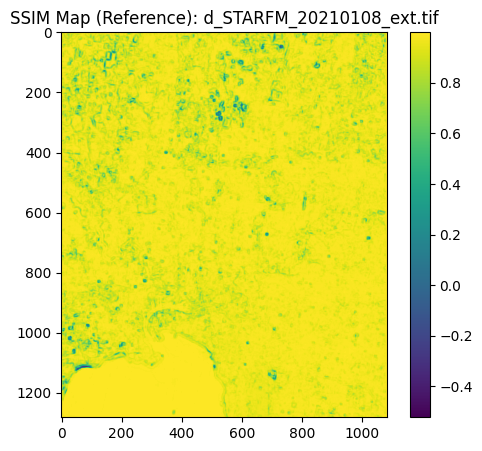

d_STARFM_20220119_ext.tif SSIM (Reference): 0.9348


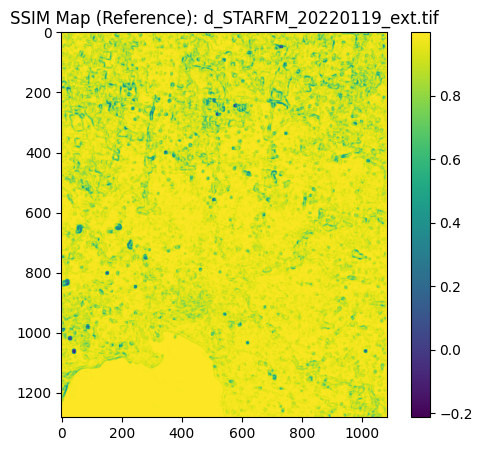

d_STARFM_20220120_ext.tif SSIM (Reference): 0.9417


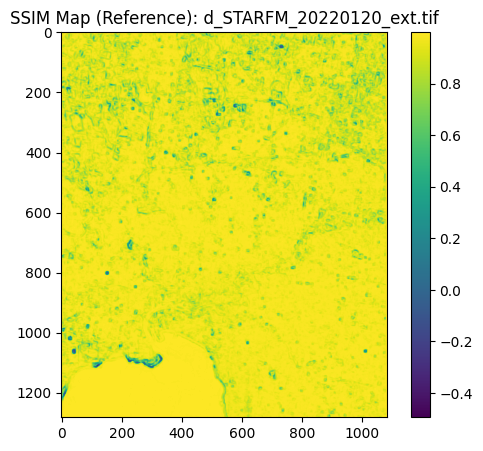

In [3]:
import numpy as np
import pandas as pd
import tifffile as tiff
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import os

# --------------------------
# File paths
# --------------------------
# Reference LST (observed)
reference_files = [
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_REFERENCE_fine_20210108_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_REFERENCE_fine_20220119_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_REFERENCE_fine_20220120_ext.tif",
]

# Prediction/Fused LST (any date)
prediction_files = [
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_STARFM_20210108_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_STARFM_20220119_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_STARFM_20220120_ext.tif",
]

# Output directory for SSIM maps
output_dir = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\SSIM_maps"
os.makedirs(output_dir, exist_ok=True)

# --------------------------
# Loop over predictions
# --------------------------
for pred_path in prediction_files:
    fused = tiff.imread(pred_path).astype(np.float32)

    # Find matching reference by date in filename
    matching_reference = None
    for ref_path in reference_files:
        if os.path.basename(ref_path).split('_')[-2] in os.path.basename(pred_path):
            matching_reference = ref_path
            break

    if matching_reference:
        base = tiff.imread(matching_reference).astype(np.float32)
        label = "Reference"
    else:
        # If no exact match, pick the first reference (or your base image)
        base = tiff.imread(reference_files[0]).astype(np.float32)
        label = "Base"

    # --------------------------
    # Replace extreme NoData values with NaN
    # --------------------------
    base[base < -1e30] = np.nan
    fused[fused < -1e30] = np.nan

    # Mask valid pixels
    mask = np.isfinite(base) & np.isfinite(fused)
    base_masked = np.where(mask, base, 0)
    fused_masked = np.where(mask, fused, 0)

    # Compute data range
    data_range = np.nanmax(base_masked) - np.nanmin(base_masked)
    if data_range == 0:
        print(f"{os.path.basename(pred_path)}: Data range zero, skipping SSIM")
        continue

    # Compute SSIM
    ssim_value, ssim_map = ssim(base_masked, fused_masked, data_range=data_range, full=True)

    print(f"{os.path.basename(pred_path)} SSIM ({label}): {ssim_value:.4f}")

    # Save SSIM map as 8-bit for visualization
    ssim_map_path = os.path.join(output_dir, f"SSIM_{label}_{os.path.basename(pred_path)}")
    tiff.imwrite(ssim_map_path, (ssim_map * 255).astype(np.uint8))

    # Optional: plot SSIM map
    plt.figure(figsize=(6,5))
    plt.imshow(ssim_map, cmap="viridis")
    plt.colorbar()
    plt.title(f"SSIM Map ({label}): {os.path.basename(pred_path)}")
    plt.show()


In [4]:
# --------------------------
# Store SSIM values for boxplot
# --------------------------
ssim_records = []

# --------------------------
# Loop over predictions
# --------------------------
for pred_path in prediction_files:
    fused = tiff.imread(pred_path).astype(np.float32)

    # Find matching reference by date in filename
    matching_reference = None
    for ref_path in reference_files:
        if os.path.basename(ref_path).split('_')[-2] in os.path.basename(pred_path):
            matching_reference = ref_path
            break

    if matching_reference:
        base = tiff.imread(matching_reference).astype(np.float32)
        comparison = "Reference"
    else:
        base = tiff.imread(reference_files[0]).astype(np.float32)
        comparison = "Base"

    # Replace extreme NoData values with NaN
    base[base < -1e30] = np.nan
    fused[fused < -1e30] = np.nan

    # Mask valid pixels
    mask = np.isfinite(base) & np.isfinite(fused)
    base_masked = np.where(mask, base, 0)
    fused_masked = np.where(mask, fused, 0)

    # Compute data range
    data_range = np.nanmax(base_masked) - np.nanmin(base_masked)
    if data_range == 0:
        continue

    # Compute SSIM
    _, ssim_map = ssim(base_masked, fused_masked,
                       data_range=data_range,
                       full=True)

    # Extract valid SSIM pixels
    valid_ssim = ssim_map[mask]

    # Extract metadata from filename
    filename = os.path.basename(pred_path)
    parts = filename.split('_')

    method = parts[1]        # STARFM / FSDAF
    date = parts[2]          # 20210108 etc.

    # Store pixel-wise SSIM
    for value in valid_ssim:
        ssim_records.append({
            "Date": date,
            "Method": method,
            "Comparison": comparison,
            "SSIM": value
        })

# --------------------------
# Convert to DataFrame
# --------------------------
ssim_df = pd.DataFrame(ssim_records)

# Save table
output_csv = os.path.join(output_dir, "SSIM_pixelwise_table.csv")
ssim_df.to_csv(output_csv, index=False)

print("SSIM table saved to:", output_csv)
print(ssim_df.head())


SSIM table saved to: C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\SSIM_maps\SSIM_pixelwise_table.csv
       Date  Method Comparison      SSIM
0  20210108  STARFM  Reference  0.992092
1  20210108  STARFM  Reference  0.992233
2  20210108  STARFM  Reference  0.992199
3  20210108  STARFM  Reference  0.992008
4  20210108  STARFM  Reference  0.991764


In [5]:
import numpy as np
import tifffile as tiff
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import os
import pandas as pd

# --------------------------
# Reference LST (observed)
# --------------------------
reference_files = [
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_REFERENCE_fine_20210108_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_REFERENCE_fine_20220119_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_REFERENCE_fine_20220120_ext.tif",
]

# Prediction/Fused LST
prediction_files = [
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_STARFM_20210108_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_STARFM_20220119_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_STARFM_20220120_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_FSDAF_20210108_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_FSDAF_20220119_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_FSDAF_20220120_ext.tif",
]

# Output directory for SSIM maps
output_dir = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\SSIM_maps"
os.makedirs(output_dir, exist_ok=True)

# --------------------------
# Prepare table to store SSIM values
# --------------------------
ssim_table = []

# --------------------------
# Loop over predictions
# --------------------------
for pred_path in prediction_files:
    fused = tiff.imread(pred_path).astype(np.float32)

    # Find matching reference by date in filename
    matching_reference = None
    for ref_path in reference_files:
        if os.path.basename(ref_path).split('_')[-2] in os.path.basename(pred_path):
            matching_reference = ref_path
            break

    if matching_reference:
        base = tiff.imread(matching_reference).astype(np.float32)
        label = "Reference"
    else:
        # fallback to first reference
        base = tiff.imread(reference_files[0]).astype(np.float32)
        label = "Base"

    # Mask extreme NoData values
    base[base < -1e30] = np.nan
    fused[fused < -1e30] = np.nan

    # Check for shape mismatch
    if base.shape != fused.shape:
        print(f"{os.path.basename(pred_path)} shape mismatch: {fused.shape} vs {base.shape}, skipping...")
        continue

    # Mask valid pixels
    mask = np.isfinite(base) & np.isfinite(fused)
    base_masked = np.where(mask, base, 0)
    fused_masked = np.where(mask, fused, 0)

    # Compute data range
    data_range = np.nanmax(base_masked) - np.nanmin(base_masked)
    if data_range == 0:
        print(f"{os.path.basename(pred_path)}: Data range zero, skipping SSIM")
        continue

    # Compute SSIM
    ssim_value, ssim_map = ssim(base_masked, fused_masked, data_range=data_range, full=True)
    print(f"{os.path.basename(pred_path)} SSIM ({label}): {ssim_value:.4f}")

    # Append to table
    ssim_table.append({"Prediction_Image": os.path.basename(pred_path),
                       "Reference_Image": os.path.basename(matching_reference) if matching_reference else "Base",
                       "SSIM": ssim_value})

    # Save SSIM map
    ssim_map_path = os.path.join(output_dir, f"SSIM_{label}_{os.path.basename(pred_path)}")
    tiff.imwrite(ssim_map_path, (ssim_map * 255).astype(np.uint8))

# --------------------------
# Export table to CSV
# --------------------------
ssim_df = pd.DataFrame(ssim_table)
csv_path = os.path.join(output_dir, "model_day_SSIM_values_table.csv")
ssim_df.to_csv(csv_path, index=False)
print(f"SSIM table saved to: {csv_path}")


d_STARFM_20210108_ext.tif SSIM (Reference): 0.9445
d_STARFM_20220119_ext.tif SSIM (Reference): 0.9348
d_STARFM_20220120_ext.tif SSIM (Reference): 0.9417
d_FSDAF_20210108_ext.tif SSIM (Reference): 0.8927
d_FSDAF_20220119_ext.tif SSIM (Reference): 0.8554
d_FSDAF_20220120_ext.tif SSIM (Reference): 0.9106
SSIM table saved to: C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\SSIM_maps\model_day_SSIM_values_table.csv


In [6]:
import numpy as np
import tifffile as tiff
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import os
import pandas as pd

# --------------------------
# Reference LST (observed)
# --------------------------
reference_files = [
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_REFERENCE_fine_20210108_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_REFERENCE_fine_20220119_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_REFERENCE_fine_20220120_ext.tif",
]

# Prediction/Fused LST
prediction_files = [
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_STARFM_20210108_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_STARFM_20220119_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_STARFM_20220120_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_FSDAF_20210108_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_FSDAF_20220119_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_FSDAF_20220120_ext.tif",
]

# Output directory for SSIM maps
output_dir = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\SSIM_maps"
os.makedirs(output_dir, exist_ok=True)
# --------------------------
# Store pixel-wise SSIM
# --------------------------
ssim_records = []

# --------------------------
# Loop
# --------------------------
for pred_path in prediction_files:

    fused = tiff.imread(pred_path).astype(np.float32)

    # Match reference by date
    matching_reference = None
    for ref_path in reference_files:
        if os.path.basename(ref_path).split('_')[-2] in os.path.basename(pred_path):
            matching_reference = ref_path
            break

    if matching_reference is None:
        continue

    base = tiff.imread(matching_reference).astype(np.float32)

    # Handle NoData
    base[base < -1e30] = np.nan
    fused[fused < -1e30] = np.nan

    if base.shape != fused.shape:
        continue

    mask = np.isfinite(base) & np.isfinite(fused)

    base_masked = np.where(mask, base, 0)
    fused_masked = np.where(mask, fused, 0)

    data_range = np.nanmax(base_masked) - np.nanmin(base_masked)
    if data_range == 0:
        continue

    # Compute pixel-wise SSIM
    _, ssim_map = ssim(
        base_masked,
        fused_masked,
        data_range=data_range,
        full=True
    )

    # Extract metadata
    filename = os.path.basename(pred_path)
    parts = filename.split('_')
    method = parts[1]
    date = parts[2]

    # Extract only valid SSIM pixels
    valid_ssim = ssim_map[mask]

    for value in valid_ssim:
        ssim_records.append({
            "Date": date,
            "Method": method,
            "SSIM": value
        })

    print(f"{filename} processed — {len(valid_ssim)} pixels stored")

# --------------------------
# Save table
# --------------------------
ssim_df = pd.DataFrame(ssim_records)

csv_path = os.path.join(output_dir, "pixelwise_SSIM_table.csv")
ssim_df.to_csv(csv_path, index=False)

print("Pixel-wise SSIM table saved to:", csv_path)
print("Total rows:", len(ssim_df))

d_STARFM_20210108_ext.tif processed — 1387323 pixels stored
d_STARFM_20220119_ext.tif processed — 1387323 pixels stored
d_STARFM_20220120_ext.tif processed — 1387323 pixels stored
d_FSDAF_20210108_ext.tif processed — 1387323 pixels stored
d_FSDAF_20220119_ext.tif processed — 1387323 pixels stored
d_FSDAF_20220120_ext.tif processed — 1387323 pixels stored
Pixel-wise SSIM table saved to: C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\SSIM_maps\pixelwise_SSIM_table.csv
Total rows: 8323938


Boxplot saved to: C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\day_reference_pixelwise_SSIM_boxplot.png


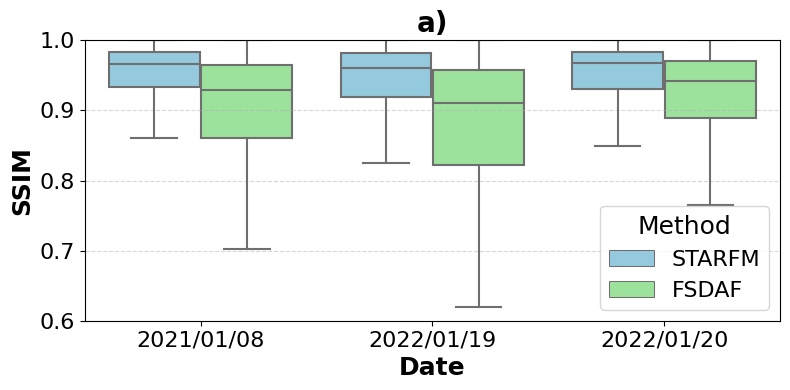

In [7]:
# SSIM daytime Boxplot
# Boxplot by Date and Method
import numpy as np
import tifffile as tiff
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

# --------------------------
# Reference LST (observed)
# --------------------------
reference_files = [
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_REFERENCE_fine_20210108_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_REFERENCE_fine_20220119_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_REFERENCE_fine_20220120_ext.tif",
]

# Prediction/Fused LST
prediction_files = [
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_STARFM_20210108_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_STARFM_20220119_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_STARFM_20220120_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_FSDAF_20210108_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_FSDAF_20220119_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_FSDAF_20220120_ext.tif",
]

# --------------------------
# Store pixel-wise SSIM
# --------------------------
ssim_records = []

# --------------------------
# Loop over predictions
# --------------------------
for pred_path in prediction_files:
    fused = tiff.imread(pred_path).astype(np.float32)

    # Match reference by date
    matching_reference = None
    for ref_path in reference_files:
        if os.path.basename(ref_path).split('_')[-2] in os.path.basename(pred_path):
            matching_reference = ref_path
            break
    if matching_reference is None:
        continue

    base = tiff.imread(matching_reference).astype(np.float32)

    # Handle NoData
    base[base < -1e30] = np.nan
    fused[fused < -1e30] = np.nan

    if base.shape != fused.shape:
        continue

    mask = np.isfinite(base) & np.isfinite(fused)
    base_masked = np.where(mask, base, 0)
    fused_masked = np.where(mask, fused, 0)

    data_range = np.nanmax(base_masked) - np.nanmin(base_masked)
    if data_range == 0:
        continue

    # Pixel-wise SSIM
    _, ssim_map = ssim(base_masked, fused_masked, data_range=data_range, full=True)

    # Extract metadata
    filename = os.path.basename(pred_path)
    parts = filename.split('_')
    method = parts[1]          # STARFM or FSDAF
    date = parts[2]            # e.g., 20210108

    # Format date as YYYY/MM/DD
    date_str = f"{date[:4]}/{date[4:6]}/{date[6:]}"


    # Append only valid pixels
    valid_ssim = ssim_map[mask]
    ssim_records.extend([(date_str, method, v) for v in valid_ssim])

# --------------------------
# Convert to DataFrame
# --------------------------
ssim_df = pd.DataFrame(ssim_records, columns=["Date", "Method", "SSIM"])

# --------------------------
# Boxplot by Date and Method (smaller plot, larger labels)
# --------------------------
plt.figure(figsize=(8,4))  # reduce figure size

sns.boxplot(
    x="Date",
    y="SSIM",
    hue="Method",
    data=ssim_df,
    palette={"STARFM":"skyblue", "FSDAF":"lightgreen"},
    showfliers=False  # hides outlier points
)
plt.title("a)", fontsize=20, fontweight='bold')  # increase title font
plt.ylabel("SSIM", fontsize=18, fontweight='bold')                    # increase y-axis label font
plt.xlabel("Date", fontsize=18, fontweight='bold')                    # increase x-axis label font
plt.ylim(0.6, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Increase tick label size
plt.xticks(fontsize=16, rotation=0)
# Set y-axis ticks every 0.10
plt.yticks(np.arange(0.6, 1.01, 0.10), fontsize=16)  # 1.01 to include 1.0

plt.legend(title="Method", title_fontsize=18, prop={'size':16})  # item font size 16

plt.tight_layout()

# -------------------------
# Save figure
# -------------------------
output_path = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\day_reference_pixelwise_SSIM_boxplot.png"
plt.savefig(output_path, dpi=300)
print("Boxplot saved to:", output_path)

plt.show()


In [8]:
# Nighttime
import numpy as np
import tifffile as tiff
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import os
import pandas as pd

# --------------------------
# Reference LST (observed)
# --------------------------
reference_files = [
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\n_REFERENCE_fine_20211212_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\n_REFERENCE_fine_20230209_ext.tif",
]

# Prediction/Fused LST
prediction_files = [
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\n_STARFM_20211212_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\n_STARFM_20230209_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\n_FSDAF_20211212_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\n_FSDAF_20230209_ext.tif",
]

# Output directory for SSIM maps
output_dir = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\SSIM_maps"
os.makedirs(output_dir, exist_ok=True)

# --------------------------
# Prepare table to store SSIM values
# --------------------------
ssim_table = []

# --------------------------
# Loop over predictions
# --------------------------
for pred_path in prediction_files:
    fused = tiff.imread(pred_path).astype(np.float32)

    # Find matching reference by date in filename
    matching_reference = None
    for ref_path in reference_files:
        if os.path.basename(ref_path).split('_')[-2] in os.path.basename(pred_path):
            matching_reference = ref_path
            break

    if matching_reference:
        base = tiff.imread(matching_reference).astype(np.float32)
        label = "Reference"
    else:
        # fallback to first reference
        base = tiff.imread(reference_files[0]).astype(np.float32)
        label = "Base"

    # Mask extreme NoData values
    base[base < -1e30] = np.nan
    fused[fused < -1e30] = np.nan

    # Check for shape mismatch
    if base.shape != fused.shape:
        print(f"{os.path.basename(pred_path)} shape mismatch: {fused.shape} vs {base.shape}, skipping...")
        continue

    # Mask valid pixels
    mask = np.isfinite(base) & np.isfinite(fused)
    base_masked = np.where(mask, base, 0)
    fused_masked = np.where(mask, fused, 0)

    # Compute data range
    data_range = np.nanmax(base_masked) - np.nanmin(base_masked)
    if data_range == 0:
        print(f"{os.path.basename(pred_path)}: Data range zero, skipping SSIM")
        continue

    # Compute SSIM
    ssim_value, ssim_map = ssim(base_masked, fused_masked, data_range=data_range, full=True)
    print(f"{os.path.basename(pred_path)} SSIM ({label}): {ssim_value:.4f}")

    # Append to table
    ssim_table.append({"Prediction_Image": os.path.basename(pred_path),
                       "Reference_Image": os.path.basename(matching_reference) if matching_reference else "Base",
                       "SSIM": ssim_value})

    # Save SSIM map
    ssim_map_path = os.path.join(output_dir, f"SSIM_{label}_{os.path.basename(pred_path)}")
    tiff.imwrite(ssim_map_path, (ssim_map * 255).astype(np.uint8))

# --------------------------
# Export table to CSV
# --------------------------
ssim_df = pd.DataFrame(ssim_table)
csv_path = os.path.join(output_dir, "model_night_SSIM_values_table.csv")
ssim_df.to_csv(csv_path, index=False)
print(f"SSIM table saved to: {csv_path}")


n_STARFM_20211212_ext.tif SSIM (Reference): 0.4637
n_STARFM_20230209_ext.tif SSIM (Reference): 0.4198
n_FSDAF_20211212_ext.tif SSIM (Reference): 0.4899
n_FSDAF_20230209_ext.tif SSIM (Reference): 0.4295
SSIM table saved to: C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\SSIM_maps\model_night_SSIM_values_table.csv


Boxplot saved to: C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\night_reference_pixelwise_SSIM_boxplot.png


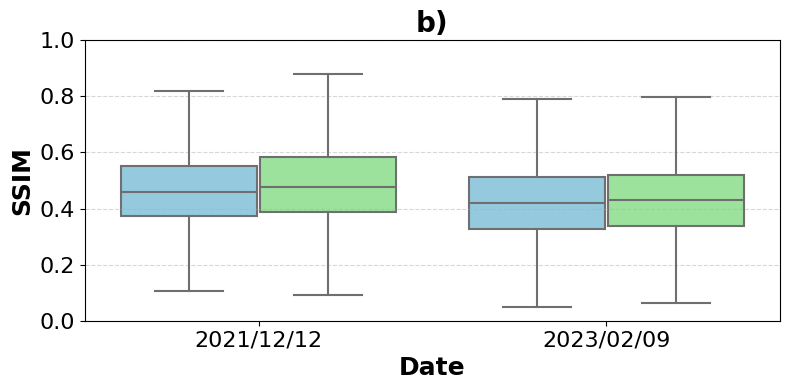

In [9]:
import numpy as np
import tifffile as tiff
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
# --------------------------
# Reference LST (observed)
# --------------------------
reference_files = [
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\n_REFERENCE_fine_20211212_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\n_REFERENCE_fine_20230209_ext.tif",
]

# Prediction/Fused LST
prediction_files = [
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\n_STARFM_20211212_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\n_STARFM_20230209_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\n_FSDAF_20211212_ext.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\n_FSDAF_20230209_ext.tif",
]


# --------------------------
# Store pixel-wise SSIM
# --------------------------
ssim_records = []

# --------------------------
# Loop over predictions
# --------------------------
for pred_path in prediction_files:
    fused = tiff.imread(pred_path).astype(np.float32)

    # Match reference by date
    matching_reference = None
    for ref_path in reference_files:
        if os.path.basename(ref_path).split('_')[-2] in os.path.basename(pred_path):
            matching_reference = ref_path
            break
    if matching_reference is None:
        continue

    base = tiff.imread(matching_reference).astype(np.float32)

    # Handle NoData
    base[base < -1e30] = np.nan
    fused[fused < -1e30] = np.nan

    if base.shape != fused.shape:
        continue

    mask = np.isfinite(base) & np.isfinite(fused)
    base_masked = np.where(mask, base, 0)
    fused_masked = np.where(mask, fused, 0)

    data_range = np.nanmax(base_masked) - np.nanmin(base_masked)
    if data_range == 0:
        continue

    # Pixel-wise SSIM
    _, ssim_map = ssim(base_masked, fused_masked, data_range=data_range, full=True)

    # Extract metadata
    filename = os.path.basename(pred_path)
    parts = filename.split('_')
    method = parts[1]          # STARFM or FSDAF
    date = parts[2]            # e.g., 20210108

    # Format date as YYYY/MM/DD
    date_str = f"{date[:4]}/{date[4:6]}/{date[6:]}"

    # Append only valid pixels
    valid_ssim = ssim_map[mask]
    ssim_records.extend([(date_str, method, v) for v in valid_ssim])

# --------------------------
# Convert to DataFrame
# --------------------------
ssim_df = pd.DataFrame(ssim_records, columns=["Date", "Method", "SSIM"])

# --------------------------
# Boxplot by Date and Method (smaller plot, larger labels)
# --------------------------
plt.figure(figsize=(8,4))  # reduce figure size

sns.boxplot(
    x="Date",
    y="SSIM",
    hue="Method",
    data=ssim_df,
    palette={"STARFM":"skyblue", "FSDAF":"lightgreen"},
    showfliers=False  # hides outlier points
)

plt.title("b)", fontsize=20, fontweight='bold')  # increase title font
plt.ylabel("SSIM", fontsize=18, fontweight='bold')                    # increase y-axis label font
plt.xlabel("Date", fontsize=18, fontweight='bold')                    # increase x-axis label font
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Increase tick label size
plt.xticks(fontsize=16, rotation=0)
plt.yticks(fontsize=16)

# Remove legend
plt.legend().remove()

#plt.legend(title="Method", title_fontsize=18, prop={'size':16})  # item font size 16

plt.tight_layout()

# -------------------------
# Save figure
# -------------------------
output_path = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\night_reference_pixelwise_SSIM_boxplot.png"
plt.savefig(output_path, dpi=300)
print("Boxplot saved to:", output_path)

plt.show()


# 5. Spatio-temporal analysis (dates without reference images)
## 5.1 Structural similarity index (SSIM)

dSTARFM_20221203.tif SSIM (vs base): 0.9842


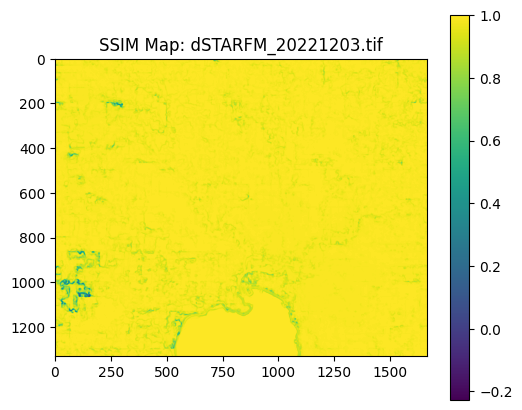

dSTARFM_20221227.tif SSIM (vs base): 0.9842


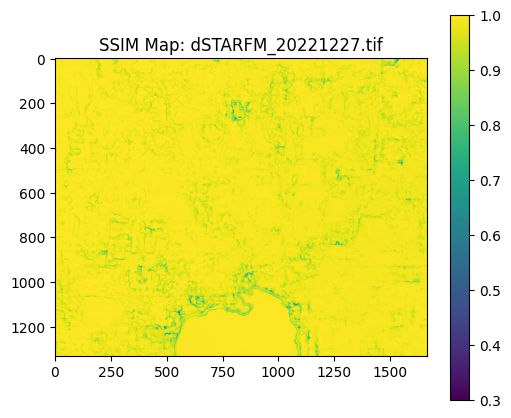

dSTARFM_20230127.tif SSIM (vs base): 0.9847


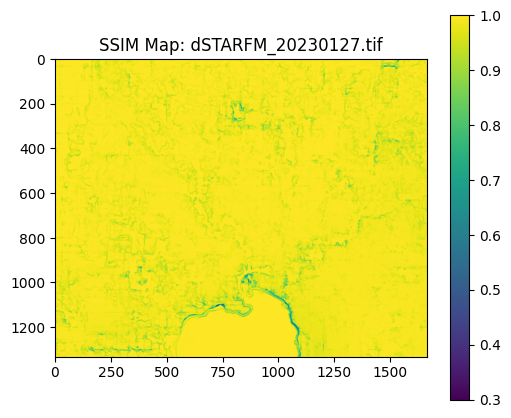

In [10]:
import numpy as np
import tifffile as tiff
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import os

# --------------------------
# Base image (used for all predictions)
# --------------------------
base_path = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_BASE_fine_20230107.tif"
base = tiff.imread(base_path).astype(np.float32)
base[base < -1e30] = np.nan  # mask extreme NoData

# --------------------------
# List all prediction dates
# --------------------------
prediction_files = [
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\dSTARFM_20221203.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\dSTARFM_20221227.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\dSTARFM_20230127.tif",
    # add more prediction dates here
]

# --------------------------
# Output folder for SSIM maps
# --------------------------
output_dir = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\SSIM_maps"
os.makedirs(output_dir, exist_ok=True)

# --------------------------
# Loop over predictions
# --------------------------
for pred_path in prediction_files:
    fused = tiff.imread(pred_path).astype(np.float32)
    fused[fused < -1e30] = np.nan  # mask NoData

    # Mask valid pixels
    mask = np.isfinite(base) & np.isfinite(fused)
    base_masked = np.where(mask, base, 0)
    fused_masked = np.where(mask, fused, 0)

    # Compute data range
    data_range = np.nanmax(base_masked) - np.nanmin(base_masked)
    if data_range == 0:
        print(f"{os.path.basename(pred_path)}: data range zero, skipping SSIM")
        continue

    # Compute SSIM
    ssim_value, ssim_map = ssim(base_masked, fused_masked, data_range=data_range, full=True)
    print(f"{os.path.basename(pred_path)} SSIM (vs base): {ssim_value:.4f}")

    # Save SSIM map
    ssim_map_path = os.path.join(output_dir, f"SSIM_{os.path.basename(pred_path)}")
    tiff.imwrite(ssim_map_path, (ssim_map * 255).astype(np.uint8))  # scaled for visualization

    # Optional: plot
    plt.figure(figsize=(6,5))
    plt.imshow(ssim_map, cmap="viridis")
    plt.colorbar()
    plt.title(f"SSIM Map: {os.path.basename(pred_path)}")
    plt.show()


Boxplot saved to: C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\fig6_aday_prediction_pixelwise_SSIM_boxplot.png


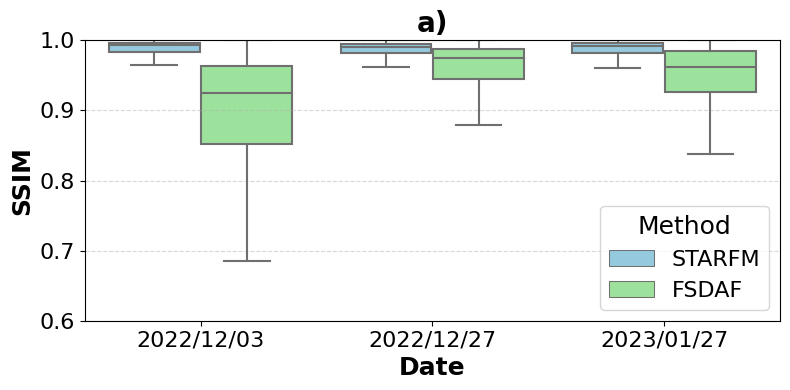

In [125]:
import numpy as np
import tifffile as tiff
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

# --------------------------
# Base image (used for all predictions)
# --------------------------
base_path = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_BASE_fine_20230107.tif"
base = tiff.imread(base_path).astype(np.float32)
base[base < -1e30] = np.nan  # mask extreme NoData

# --------------------------
# List all prediction dates
# --------------------------
prediction_files = [
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\dSTARFM_20221203.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\dSTARFM_20221227.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\dSTARFM_20230127.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_FSDAF_20221203.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_FSDAF_20221227.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_FSDAF_20230127.tif",
]

# --------------------------
# Store pixel-wise SSIM
# --------------------------
ssim_records = []

for pred_path in prediction_files:
    fused = tiff.imread(pred_path).astype(np.float32)
    fused[fused < -1e30] = np.nan  # mask NoData

    if base.shape != fused.shape:
        print(f"{os.path.basename(pred_path)} shape mismatch, skipping...")
        continue

    mask = np.isfinite(base) & np.isfinite(fused)
    base_masked = np.where(mask, base, 0)
    fused_masked = np.where(mask, fused, 0)

    data_range = np.nanmax(base_masked) - np.nanmin(base_masked)
    if data_range == 0:
        continue

    # Pixel-wise SSIM
    _, ssim_map = ssim(base_masked, fused_masked, data_range=data_range, full=True)

    # Extract metadata
    filename = os.path.basename(pred_path)
    method = "STARFM" if "STARFM" in filename else "FSDAF"
    date = filename.split('_')[-1].split('.')[0]  # e.g., 20221203
    date_str = f"{date[:4]}-{date[4:6]}-{date[6:]}"  # YYYY-MM-DD

    # Append only valid pixels
    valid_ssim = ssim_map[mask]
    ssim_records.extend([(date_str, method, v) for v in valid_ssim])

# --------------------------
# Convert to DataFrame
# --------------------------
ssim_df = pd.DataFrame(ssim_records, columns=["Date", "Method", "SSIM"])

# --------------------------
# Boxplot
# --------------------------
plt.figure(figsize=(8,4))

# Reformat dates in the DataFrame to YYYY/MM/DD
ssim_df['Date'] = pd.to_datetime(ssim_df['Date']).dt.strftime('%Y/%m/%d')


sns.boxplot(
    x="Date",
    y="SSIM",
    hue="Method",
    data=ssim_df,
    palette={"STARFM":"skyblue", "FSDAF":"lightgreen"},
    showfliers=False
)

plt.title("a)", fontsize=20, fontweight='bold')  # increase title font
plt.ylabel("SSIM", fontsize=18, fontweight='bold')                    # increase y-axis label font
plt.xlabel("Date", fontsize=18, fontweight='bold')                    # increase x-axis label font
plt.ylim(0.6, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Increase tick label size
plt.xticks(fontsize=16, rotation=0)
# Set y-axis ticks every 0.10
plt.yticks(np.arange(0.6, 1.01, 0.10), fontsize=16)  # 1.01 to include 1.0

# Remove legend
#plt.legend().remove()

plt.legend(title="Method", title_fontsize=18, prop={'size':16})  # item font size 16

plt.tight_layout()

# --------------------------
# Save figure
# --------------------------
output_path = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\fig6_a_day_prediction_pixelwise_SSIM_boxplot.png"
plt.savefig(output_path, dpi=300)
print("Boxplot saved to:", output_path)

plt.show()


In [12]:
import numpy as np
import tifffile as tiff
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import os
import pandas as pd  # for creating the table

# --------------------------
# Base image (used for all predictions)
# --------------------------
base_path = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_BASE_fine_20230107.tif"
base = tiff.imread(base_path).astype(np.float32)
base[base < -1e30] = np.nan  # mask extreme NoData

# --------------------------
# List all prediction dates
# --------------------------
prediction_files = [
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\dSTARFM_20221203.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\dSTARFM_20221227.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\dSTARFM_20230127.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_FSDAF_20221203.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_FSDAF_20221227.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_FSDAF_20230127.tif",
]

# --------------------------
# Output folder for SSIM maps
# --------------------------
output_dir = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\SSIM_maps"
os.makedirs(output_dir, exist_ok=True)

# --------------------------
# Prepare table to store SSIM values
# --------------------------
ssim_table = []

# --------------------------
# Loop over predictions
# --------------------------
for pred_path in prediction_files:
    fused = tiff.imread(pred_path).astype(np.float32)
    fused[fused < -1e30] = np.nan  # mask NoData

    # --------------------------
    # Check for shape mismatch
    # --------------------------
    if fused.shape != base.shape:
        print(f"{os.path.basename(pred_path)} shape mismatch: {fused.shape} vs {base.shape}, skipping...")
        continue

    # Mask valid pixels
    mask = np.isfinite(base) & np.isfinite(fused)
    base_masked = np.where(mask, base, 0)
    fused_masked = np.where(mask, fused, 0)

    # Compute data range
    data_range = np.nanmax(base_masked) - np.nanmin(base_masked)
    if data_range == 0:
        print(f"{os.path.basename(pred_path)}: data range zero, skipping SSIM")
        continue

    # Compute SSIM
    ssim_value, ssim_map = ssim(base_masked, fused_masked, data_range=data_range, full=True)
    print(f"{os.path.basename(pred_path)} SSIM (vs base): {ssim_value:.4f}")

    # Append to table
    ssim_table.append({"Prediction_Image": os.path.basename(pred_path), "SSIM": ssim_value})

    # Save SSIM map
    ssim_map_path = os.path.join(output_dir, f"SSIM_{os.path.basename(pred_path)}")
    tiff.imwrite(ssim_map_path, (ssim_map * 255).astype(np.uint8))  # scaled for visualization

# --------------------------
# Export table to CSV
# --------------------------
ssim_df = pd.DataFrame(ssim_table)
csv_path = os.path.join(output_dir, "day_SSIM_values_table.csv")
ssim_df.to_csv(csv_path, index=False)
print(f"SSIM table saved to: {csv_path}")


dSTARFM_20221203.tif SSIM (vs base): 0.9842
dSTARFM_20221227.tif SSIM (vs base): 0.9842
dSTARFM_20230127.tif SSIM (vs base): 0.9847
d_FSDAF_20221203.tif SSIM (vs base): 0.8739
d_FSDAF_20221227.tif SSIM (vs base): 0.9488
d_FSDAF_20230127.tif SSIM (vs base): 0.9429
SSIM table saved to: C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\SSIM_maps\day_SSIM_values_table.csv


In [13]:
import numpy as np
import tifffile as tiff
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import os
import pandas as pd  # for creating the table

# --------------------------
# Base image (used for all predictions)
# --------------------------
base_path = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\nn_BASE_20221225.tif"
base = tiff.imread(base_path).astype(np.float32)
base[base < -1e30] = np.nan  # mask extreme NoData

# --------------------------
# List all prediction dates
# --------------------------
prediction_files = [
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\nSTARFM_20221203.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\nSTARFM_20221227.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\nSTARFM_20230107.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\nSTARFM_20230127.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\n_FSDAF_20221203.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\n_FSDAF_20221227.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\n_FSDAF_20230107.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\n_FSDAF_20230127.tif",
]

# --------------------------
# Output folder for SSIM maps
# --------------------------
output_dir = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\SSIM_maps"
os.makedirs(output_dir, exist_ok=True)

# --------------------------
# Prepare table to store SSIM values
# --------------------------
ssim_table = []

# --------------------------
# Loop over predictions
# --------------------------
for pred_path in prediction_files:
    fused = tiff.imread(pred_path).astype(np.float32)
    fused[fused < -1e30] = np.nan  # mask NoData

    # --------------------------
    # Check for shape mismatch
    # --------------------------
    if fused.shape != base.shape:
        print(f"{os.path.basename(pred_path)} shape mismatch: {fused.shape} vs {base.shape}, skipping...")
        continue

    # Mask valid pixels
    mask = np.isfinite(base) & np.isfinite(fused)
    base_masked = np.where(mask, base, 0)
    fused_masked = np.where(mask, fused, 0)

    # Compute data range
    data_range = np.nanmax(base_masked) - np.nanmin(base_masked)
    if data_range == 0:
        print(f"{os.path.basename(pred_path)}: data range zero, skipping SSIM")
        continue

    # Compute SSIM
    ssim_value, ssim_map = ssim(base_masked, fused_masked, data_range=data_range, full=True)
    print(f"{os.path.basename(pred_path)} SSIM (vs base): {ssim_value:.4f}")

    # Append to table
    ssim_table.append({"Prediction_Image": os.path.basename(pred_path), "SSIM": ssim_value})

    # Save SSIM map
    ssim_map_path = os.path.join(output_dir, f"SSIM_{os.path.basename(pred_path)}")
    tiff.imwrite(ssim_map_path, (ssim_map * 255).astype(np.uint8))  # scaled for visualization

# --------------------------
# Export table to CSV
# --------------------------
ssim_df = pd.DataFrame(ssim_table)
csv_path = os.path.join(output_dir, "night_SSIM_values_table.csv")
ssim_df.to_csv(csv_path, index=False)
print(f"SSIM table saved to: {csv_path}")


nSTARFM_20221203.tif SSIM (vs base): 0.9947
nSTARFM_20221227.tif SSIM (vs base): 0.9355
nSTARFM_20230107.tif SSIM (vs base): 0.9860
nSTARFM_20230127.tif SSIM (vs base): 0.9914
n_FSDAF_20221203.tif SSIM (vs base): 0.9889
n_FSDAF_20221227.tif SSIM (vs base): 0.8749
n_FSDAF_20230107.tif SSIM (vs base): 0.9731
n_FSDAF_20230127.tif SSIM (vs base): 0.9448
SSIM table saved to: C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\SSIM_maps\night_SSIM_values_table.csv


Boxplot saved to: C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\fig6_b_night_prediction_pixelwise_SSIM_boxplot.png


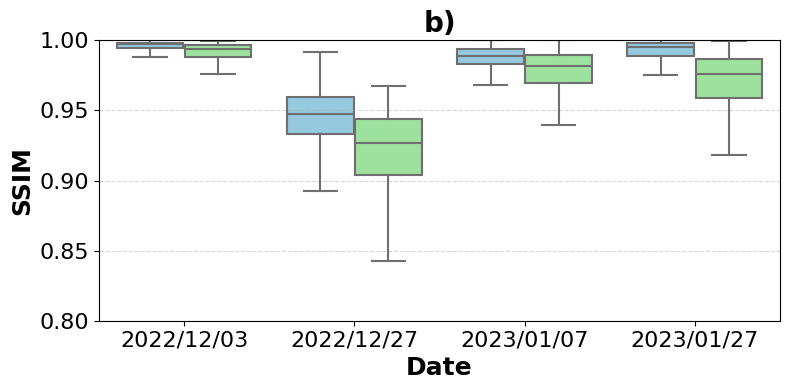

In [124]:
import numpy as np
import tifffile as tiff
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import os
import pandas as pd  # for creating the table

# --------------------------
# Base image (used for all predictions)
# --------------------------
base_path = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\nn_BASE_20221225.tif"
base = tiff.imread(base_path).astype(np.float32)
base[base < -1e30] = np.nan  # mask extreme NoData

# --------------------------
# List all prediction dates
# --------------------------
prediction_files = [
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\nSTARFM_20221203.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\nSTARFM_20221227.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\nSTARFM_20230107.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\nSTARFM_20230127.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\n_FSDAF_20221203.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\n_FSDAF_20221227.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\n_FSDAF_20230107.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\night\n_FSDAF_20230127.tif",
]

# --------------------------
# Store pixel-wise SSIM
# --------------------------
ssim_records = []

for pred_path in prediction_files:
    fused = tiff.imread(pred_path).astype(np.float32)
    fused[fused < -1e30] = np.nan  # mask NoData

    if base.shape != fused.shape:
        print(f"{os.path.basename(pred_path)} shape mismatch, skipping...")
        continue

    mask = np.isfinite(base) & np.isfinite(fused)
    base_masked = np.where(mask, base, 0)
    fused_masked = np.where(mask, fused, 0)

    data_range = np.nanmax(base_masked) - np.nanmin(base_masked)
    if data_range == 0:
        continue

    # Pixel-wise SSIM
    _, ssim_map = ssim(base_masked, fused_masked, data_range=data_range, full=True)

    # Extract metadata
    filename = os.path.basename(pred_path)
    method = "STARFM" if "STARFM" in filename else "FSDAF"
    date = filename.split('_')[-1].split('.')[0]  # e.g., 20221203
    date_str = f"{date[:4]}-{date[4:6]}-{date[6:]}"  # YYYY-MM-DD

    # Append only valid pixels
    valid_ssim = ssim_map[mask]
    ssim_records.extend([(date_str, method, v) for v in valid_ssim])

# --------------------------
# Convert to DataFrame
# --------------------------
ssim_df = pd.DataFrame(ssim_records, columns=["Date", "Method", "SSIM"])

# --------------------------
# Boxplot
# --------------------------
plt.figure(figsize=(8,4))

# Reformat dates in the DataFrame to YYYY/MM/DD
ssim_df['Date'] = pd.to_datetime(ssim_df['Date']).dt.strftime('%Y/%m/%d')

sns.boxplot(
    x="Date",
    y="SSIM",
    hue="Method",
    data=ssim_df,
    palette={"STARFM":"skyblue", "FSDAF":"lightgreen"},
    showfliers=False
)

plt.title("b)", fontsize=20, fontweight='bold')  # increase title font
plt.ylabel("SSIM", fontsize=18, fontweight='bold')                    # increase y-axis label font
plt.xlabel("Date", fontsize=18, fontweight='bold')                    # increase x-axis label font
plt.ylim(0.8, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Increase tick label size
plt.xticks(fontsize=16, rotation=0)
# Set y-axis ticks every 0.10
plt.yticks(np.arange(0.8, 1.01, 0.05), fontsize=16)  # 1.01 to include 1.0

# Remove legend
plt.legend().remove()

#plt.legend(title="Method", title_fontsize=18, prop={'size':16})  # item font size 16

plt.tight_layout()

# --------------------------
# Save figure
# --------------------------
output_path = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\fig6_b_night_prediction_pixelwise_SSIM_boxplot.png"
plt.savefig(output_path, dpi=300)
print("Boxplot saved to:", output_path)

plt.show()



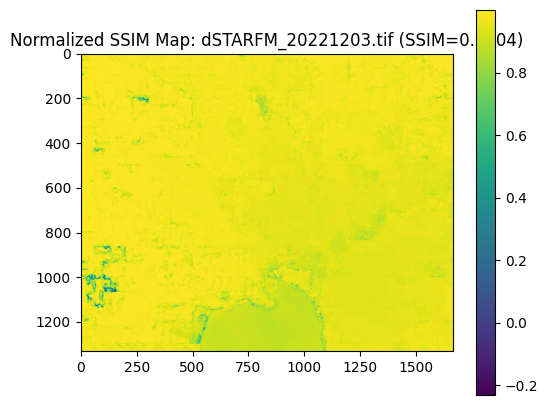

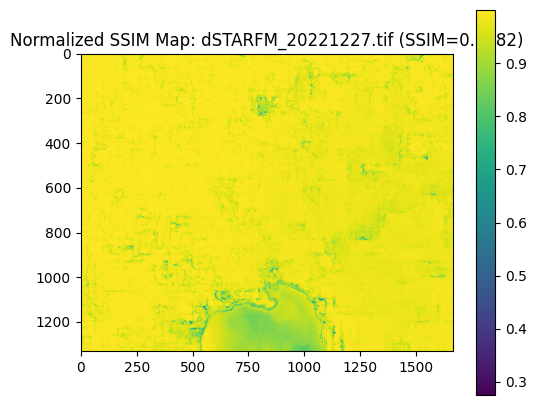

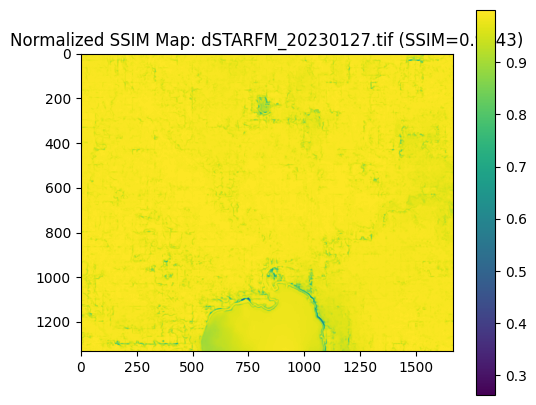

✅ SSIM computation finished. Summary CSV saved at: C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\SSIM_maps\SSIM_summary.csv


In [15]:
import numpy as np
import tifffile as tiff
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import os
import csv

# --------------------------
# Base image (used for all predictions)
# --------------------------
base_path = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\d_BASE_fine_20230107.tif"
base = tiff.imread(base_path).astype(np.float32)
base[base < -1e30] = np.nan  # mask extreme NoData

# --------------------------
# List all prediction dates
# --------------------------
prediction_files = [
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\dSTARFM_20221203.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\dSTARFM_20221227.tif",
    r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\day\dSTARFM_20230127.tif",
]

# --------------------------
# Output folder for SSIM maps
# --------------------------
output_dir = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\raster\SSIM_maps"
os.makedirs(output_dir, exist_ok=True)

# CSV to store SSIM values
csv_path = os.path.join(output_dir, "SSIM_summary.csv")
with open(csv_path, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["Prediction_File", "SSIM_direct", "SSIM_normalized"])

    # --------------------------
    # Loop over predictions
    # --------------------------
    for pred_path in prediction_files:
        fused = tiff.imread(pred_path).astype(np.float32)
        fused[fused < -1e30] = np.nan  # mask NoData

        # Mask valid pixels
        mask = np.isfinite(base) & np.isfinite(fused)
        base_masked = np.where(mask, base, 0)
        fused_masked = np.where(mask, fused, 0)

        # Data range for direct LST
        data_range = np.nanmax(base_masked) - np.nanmin(base_masked)
        if data_range == 0:
            print(f"{os.path.basename(pred_path)}: data range zero, skipping SSIM")
            continue

        # ---- SSIM on direct LST ----
        ssim_direct, ssim_map_direct = ssim(base_masked, fused_masked, data_range=data_range, full=True)

        # ---- SSIM on normalized LST ----
        base_norm = (base_masked - np.nanmin(base_masked)) / (np.nanmax(base_masked) - np.nanmin(base_masked))
        fused_norm = (fused_masked - np.nanmin(fused_masked)) / (np.nanmax(fused_masked) - np.nanmin(fused_masked))
        ssim_norm, ssim_map_norm = ssim(base_norm, fused_norm, data_range=1.0, full=True)

        # Save SSIM maps
        tiff.imwrite(os.path.join(output_dir, f"SSIM_direct_{os.path.basename(pred_path)}"), (ssim_map_direct * 255).astype(np.uint8))
        tiff.imwrite(os.path.join(output_dir, f"SSIM_norm_{os.path.basename(pred_path)}"), (ssim_map_norm * 255).astype(np.uint8))

        # Write to CSV
        writer.writerow([os.path.basename(pred_path), ssim_direct, ssim_norm])

        # Optional: plot normalized SSIM map
        plt.figure(figsize=(6,5))
        plt.imshow(ssim_map_norm, cmap="viridis")
        plt.colorbar()
        plt.title(f"Normalized SSIM Map: {os.path.basename(pred_path)} (SSIM={ssim_norm:.4f})")
        plt.show()

print("✅ SSIM computation finished. Summary CSV saved at:", csv_path)


## 5.2  Directional ring profiling using the urban-rural LST gradients
Direction-Enhanced Adaptive Synchronous Extraction (DEASE) from (Yang et al., 2026)

- Construction and division of buffers (1 km) for 21 cardinal directions
- Extraction of LST
- Comparison of LST profile by date (weather/atmospheric variability) and by direction (spatial anisotropy/urban morphology)

### 5.2.1 Zonal Statistics
Zonal statistics were applied to:
- **STARFM** outputs for **daytime LST prediction**
- **FSDAF** outputs for **night-time LST prediction**

For each prediction date, the **mean Land Surface Temperature (LST)** was extracted:
- by **date**, and  
- by **direction** (12 radial directions),

using zones defined from the **centre point of the image**.

<img src="jpg/accuracy_DEASE_bearing_centre_point.jpg" width="1200"/>

### 5.2.2 Data analysis

In [16]:
import pandas as pd
import glob
import os

# Folder containing your CSV files
dease_csv_folder = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\DEASE_csv"

# Get all CSV files
csv_files = glob.glob(os.path.join(dease_csv_folder, "*.csv"))

# Read and concatenate
dease_all_df = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

# Rename columns
dease_all_df = dease_all_df.rename(columns={
    "ID": "id",
    "MEAN": "mean_lst"
})

# Keep only relevant columns
dease_all_df = dease_all_df[["temporal", "date", "id", "mean_lst"]]

# Load the Constructed DEASE CSV metadata
buffer_df = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\constructed_buffers_metadata.csv")

# Make sure 'id' is string for merging
dease_all_df["id"] = dease_all_df["id"].astype(str)
buffer_df["id"] = buffer_df["id"].astype(str)

# Join with the metadata
dease_all_df_metadata = dease_all_df.merge(buffer_df, on="id", how="left")   

## Ensure the "Centre of urban areas" has rows for each bearing
# Filter DEASE for centre of urban areas --> distance == 0
dease_centre = dease_all_df_metadata[dease_all_df_metadata["distance"] == 0]

# DEASE centre, Bearing 255, 285, 315, 345, (15 is already in the dataset), ...
dease_centre_45 = dease_centre.copy()
dease_centre_45["direction"] = 45

dease_centre_75 = dease_centre.copy()
dease_centre_75["direction"] = 75

dease_centre_105 = dease_centre.copy()
dease_centre_105["direction"] = 105

dease_centre_135 = dease_centre.copy()
dease_centre_135["direction"] = 135

dease_centre_165 = dease_centre.copy()
dease_centre_165["direction"] = 165

dease_centre_195 = dease_centre.copy()
dease_centre_195["direction"] = 195

dease_centre_225 = dease_centre.copy()
dease_centre_225["direction"] = 225

dease_centre_255 = dease_centre.copy()
dease_centre_255["direction"] = 255

dease_centre_285 = dease_centre.copy()
dease_centre_285["direction"] = 285

dease_centre_315 = dease_centre.copy()
dease_centre_315["direction"] = 315

dease_centre_345 = dease_centre.copy()
dease_centre_345["direction"] = 345

# Concatenate all centre rows
dease_centre_all = pd.concat([
    dease_centre_45,
    dease_centre_75,
    dease_centre_105,
    dease_centre_135,
    dease_centre_165,
    dease_centre_195,
    dease_centre_225,
    dease_centre_255,
    dease_centre_285,
    dease_centre_315,
    dease_centre_345,    
], ignore_index=True)

# Combine with the original DEASE dataset
dease_all_df_metadata = pd.concat([dease_all_df_metadata, dease_centre_all], ignore_index=True)

# Create column named "use" 
dease_all_df_metadata["use"] = "prediction"  # Default to "prediction"

# Select data for daytime and nighttime separately
dease_all_df_metadata_day = dease_all_df_metadata[dease_all_df_metadata["temporal"] == "day"].copy()
dease_all_df_metadata_night = dease_all_df_metadata[dease_all_df_metadata["temporal"] == "night"].copy()

# For daytime, change the "use" to base if the date is 7/01/2023
dease_all_df_metadata_day.loc[dease_all_df_metadata_day["date"] == "7/01/2023", "use"] = "base"
# For nighttime, change the "use" to base if the date is 25/12/2022
dease_all_df_metadata_night.loc[dease_all_df_metadata_night["date"] == "25/12/2022", "use"] = "base"

# Combine back the daytime and nighttime datasets
dease_all_df_metadata_final = pd.concat([dease_all_df_metadata_day, dease_all_df_metadata_night], ignore_index=True)

# Save merged CSV
out_csv = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\dease_all_dates.csv"
dease_all_df_metadata_final.to_csv(out_csv, index=False)

dease_all_df_metadata_final.head()

,temporal,date,id,mean_lst,distance,direction,area,use
0,day,3/12/2022,361,37.179070,0,15,0.900000,prediction
1,day,3/12/2022,1,39.077419,1,165,26.158868,prediction
2,day,3/12/2022,2,38.719252,2,165,78.532089,prediction
3,day,3/12/2022,3,38.779878,3,165,130.916650,prediction
4,day,3/12/2022,4,38.709621,4,165,183.310422,prediction


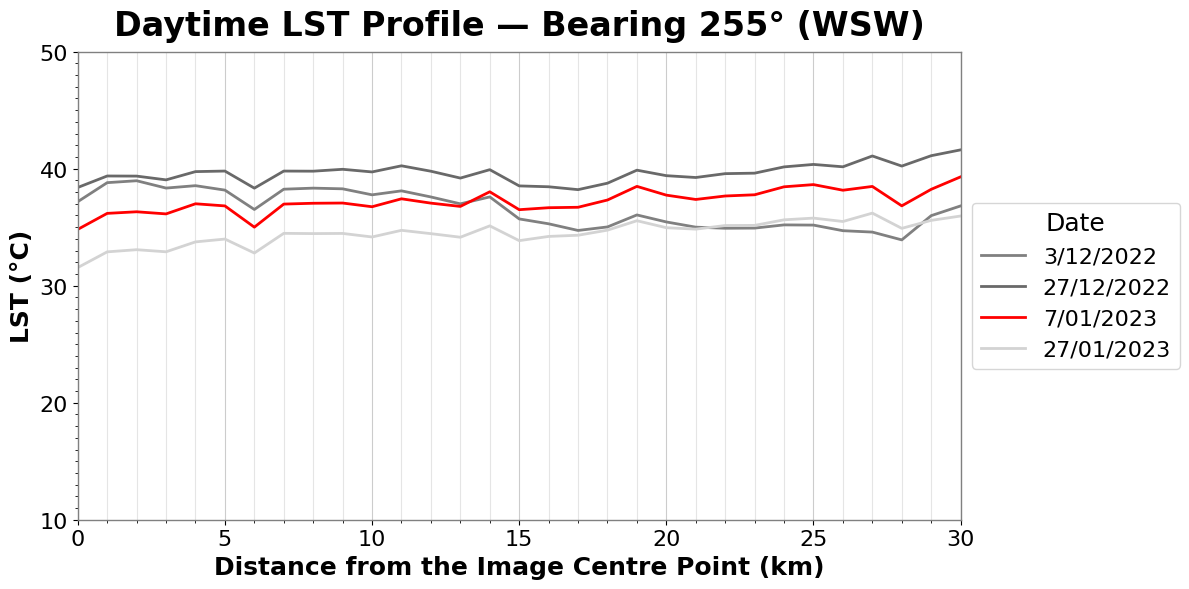

In [67]:
# Plot - One sample row from the DEASE dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Copy the dease csv file to a shorter name
dease_df = dease_all_df_metadata.copy()

# Filter for direction and temporal
dease_df_day_255 = dease_df[(dease_df["direction"] == 255) & (dease_df["temporal"] == "day")]

# Cubic smoothing spline per date
dease_df_day_255_raw = (
    dease_df_day_255[["date", "distance", "mean_lst"]]
    .sort_values(["date", "distance"])
    .reset_index(drop=True)
)

# Order dates (oldest --> newest)
date_order = [
    "3/12/2022",
    "27/12/2022",
    "7/01/2023",
    "27/01/2023"
]

dease_df_day_255_raw["date"] = pd.Categorical(
    dease_df_day_255_raw["date"],
    categories=date_order,
    ordered=True
)

# Define colours
date_colors = {
    "3/12/2022":  "gray",
    "27/12/2022": "dimgray",
    "7/01/2023":  "red",
    "27/01/2023": "lightgray"
}

# Plot smoothed curves
fig, ax = plt.subplots(figsize=(12, 6))

for date, g in dease_df_day_255_raw.groupby("date"):
    ax.plot(
        g["distance"],
        g["mean_lst"],
        label=date,
        color=date_colors.get(date, "gray"),
        linewidth=2
    )

# Axis labels and title
ax.set_xlim(0, 30)
ax.set_ylim(10, 50)

ax.set_xticks(np.arange(0, 31, 5))
ax.set_xticks(np.arange(0, 31, 1), minor=True)

ax.set_yticks(np.arange(10, 51, 10))
ax.set_yticks(np.arange(10, 51, 1), minor=True)


# labels and title
ax.set_title("Daytime LST Profile — Bearing 255° (WSW)", fontsize=24, fontweight="bold", pad=12)

ax.set_xlabel("Distance from the Image Centre Point (km)", fontsize=18, fontweight="bold")
ax.set_ylabel("LST (°C)", fontsize=18, fontweight="bold")

# Grid, legend, Styling 
ax.grid(which="major", axis="x", color="grey", alpha=0.4)
ax.grid(which="minor", axis="x", color="grey", alpha=0.2)

ax.tick_params(axis="both", labelsize=16)

legend = ax.legend(
    title="Date",
    fontsize=16,
    title_fontsize=18,
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

for spine in ax.spines.values():
    spine.set_color("grey")
    spine.set_linewidth(1)

plt.tight_layout()
plt.show()

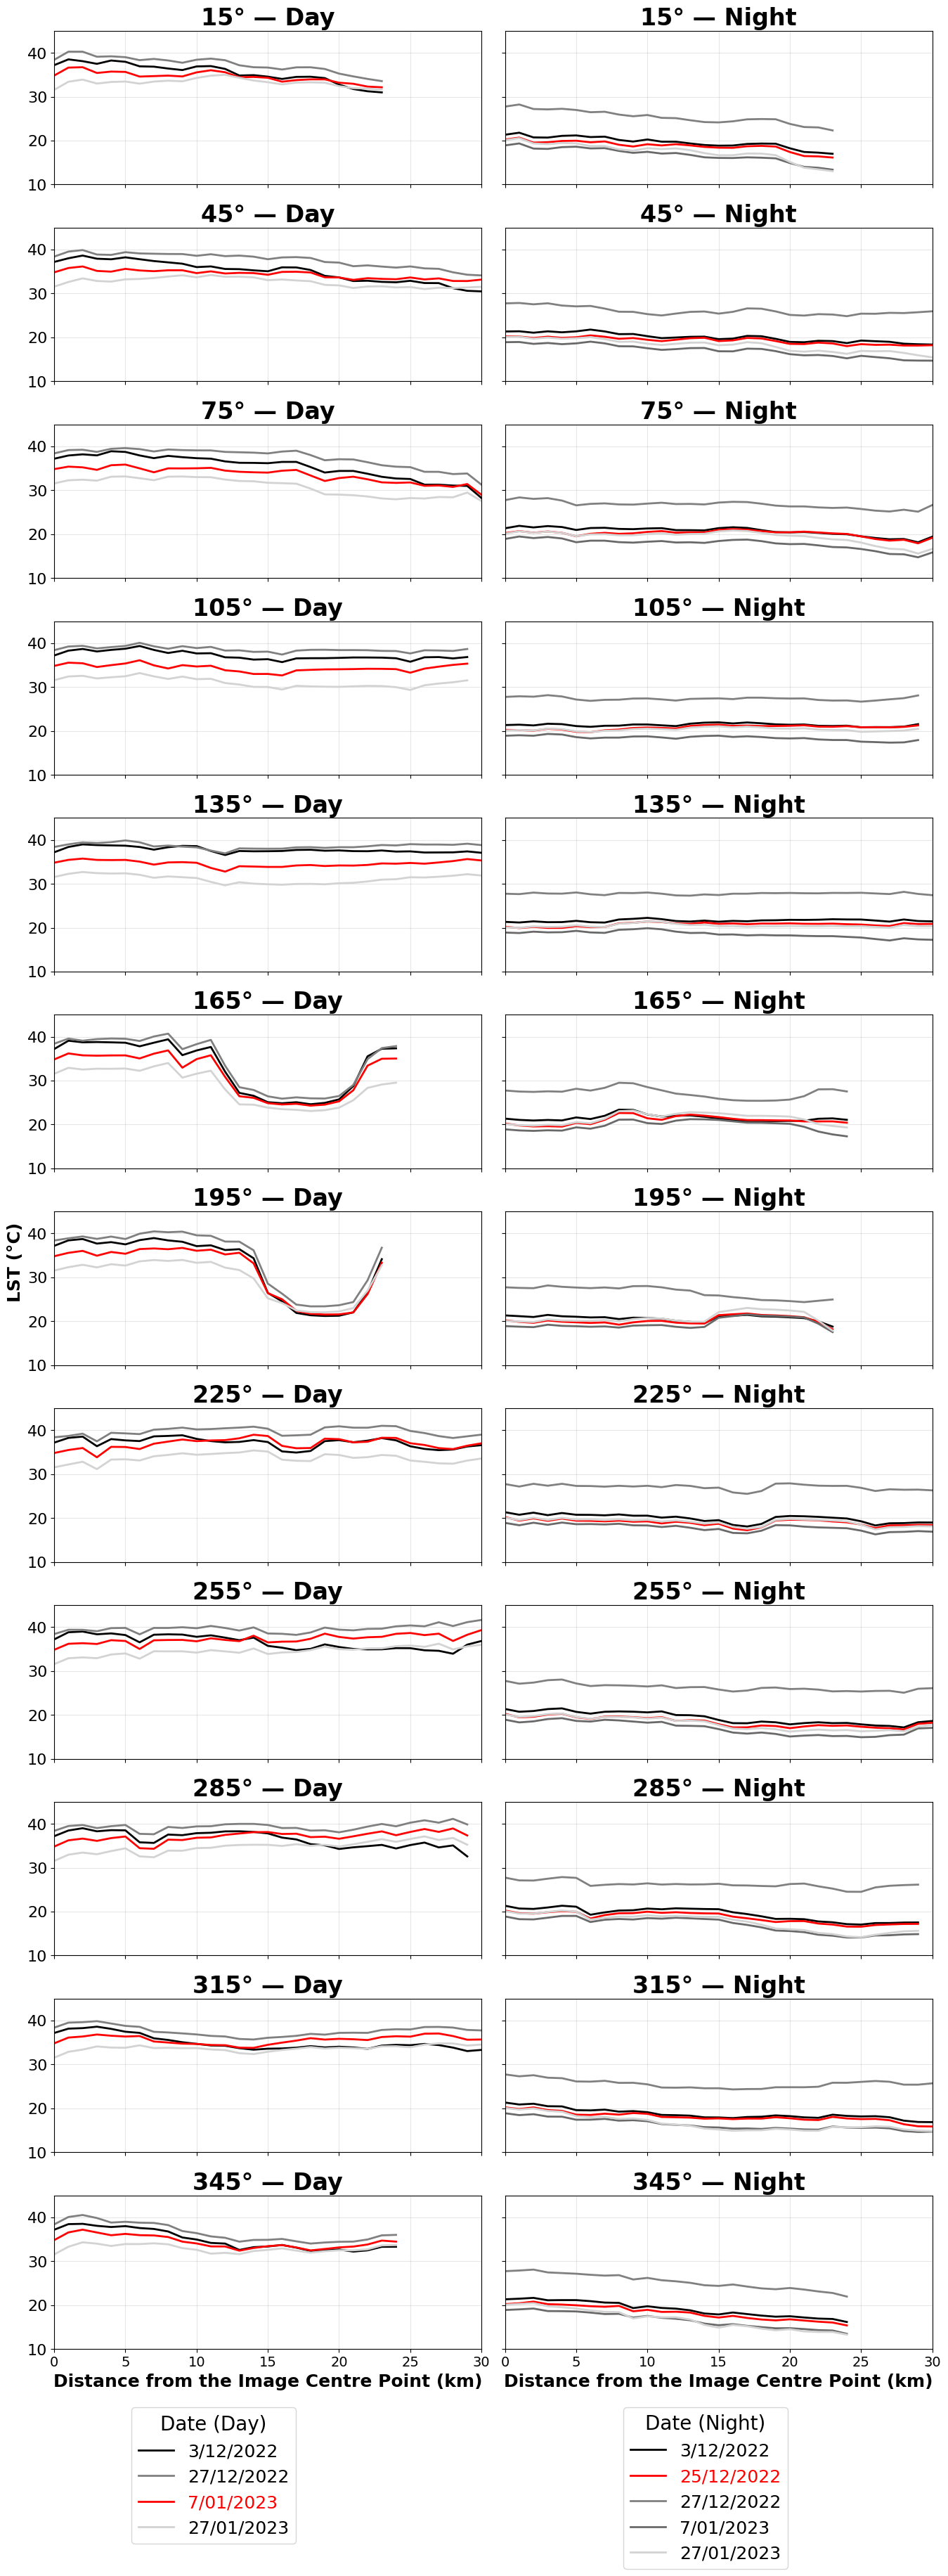

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Filter
dease_df_day = dease_df[dease_df["temporal"] == "day"]
dease_df_night = dease_df[dease_df["temporal"] == "night"]

# Define colours
date_colors_day = {
    "3/12/2022":  "black",
    "27/12/2022": "gray",
    "7/01/2023":  "red",
    "27/01/2023": "lightgray"
}

date_order_day = ["3/12/2022", "27/12/2022", "7/01/2023", "27/01/2023"]


# Define colours
date_colors_night = {
    "3/12/2022":  "black",
    "25/12/2022": "red",
    "27/12/2022": "gray",
    "7/01/2023":  "dimgray",
    "27/01/2023": "lightgray"
}

date_order_night = ["3/12/2022", "25/12/2022", "27/12/2022", "7/01/2023", "27/01/2023"]

bearings = sorted(dease_df["direction"].unique())

fig, axes = plt.subplots(
    nrows=len(bearings),
    ncols=2,
    figsize=(14, 3 * len(bearings)),
    sharex=True,
    sharey=True
)

# If only one bearing
if len(bearings) == 1:
    axes = np.array([axes])

for i, bearing in enumerate(bearings):

    ax_day = axes[i, 0]
    ax_night = axes[i, 1]

    # -------- DAY --------
    df_day = (
        dease_df_day[dease_df_day["direction"] == bearing]
        [["date", "distance", "mean_lst"]]
        .sort_values(["date", "distance"])
    )

    df_day["date"] = pd.Categorical(
        df_day["date"],
        categories=date_order_day,
        ordered=True
    )

    for date, g in df_day.groupby("date"):
        ax_day.plot(
            g["distance"],
            g["mean_lst"],
            label=date,
            color=date_colors_day.get(date, "gray"),
            linewidth=2
        )

    ax_day.set_title(f"{bearing}° — Day", fontsize=24, fontweight="bold")
    ax_day.grid(alpha=0.3)

    # -------- NIGHT --------
    df_night = (
        dease_df_night[dease_df_night["direction"] == bearing]
        [["date", "distance", "mean_lst"]]
        .sort_values(["date", "distance"])
    )

    df_night["date"] = pd.Categorical(
        df_night["date"],
        categories=date_order_night,
        ordered=True
    )

    for date, g in df_night.groupby("date"):
        ax_night.plot(
            g["distance"],
            g["mean_lst"],
            label=date,
            color=date_colors_night.get(date, "gray"),
            linewidth=2
        )

    ax_night.set_title(f"{bearing}° — Night", fontsize=24, fontweight="bold")
    ax_night.grid(alpha=0.3)

# Axis limits
for ax_row in axes:
    for ax in ax_row:
        ax.set_xlim(0, 30)
        ax.set_ylim(10, 45)
        ax.set_yticks(np.arange(10, 46, 10))

# Increase tick label sizes
for ax_row in axes:
    for ax in ax_row:
        ax.tick_params(axis="y", labelsize=16)
        ax.tick_params(axis="x", labelsize=14)

# Shared labels
axes[-1, 0].set_xlabel("Distance from the Image Centre Point (km)", fontsize=18, fontweight="bold")
axes[-1, 1].set_xlabel("Distance from the Image Centre Point (km)", fontsize=18, fontweight="bold")

fig.text(0.04, 0.5, "LST (°C)", va='center', rotation='vertical',
         fontsize=18, fontweight="bold")

# --- Day legend (vertical) ---
handles_day, labels_day = axes[0, 0].get_legend_handles_labels()

legend_day = fig.legend(
    handles_day,
    labels_day,
    title="Date (Day)",
    loc="lower center",
    ncol=1,             # vertical stack
    fontsize=18,
    title_fontsize=20,
    bbox_to_anchor=(0.25, -0.01)  # center under the left column
)

# Color one label red
for text in legend_day.get_texts():
    if text.get_text() == "7/01/2023":
        text.set_color("red")

# --- Night legend (vertical) ---
handles_night, labels_night = axes[0, 1].get_legend_handles_labels()

legend_night = fig.legend(
    handles_night,
    labels_night,
    title="Date (Night)",
    loc="lower center",
    ncol=1,
    fontsize=18,
    title_fontsize=20,
    bbox_to_anchor=(0.75, -0.02)
)

# Color one label red
for text in legend_night.get_texts():
    if text.get_text() == "25/12/2022":
        text.set_color("red")

plt.tight_layout(rect=[0.05, 0.05, 1, 1])
plt.show()

# Save the figure
fig.savefig(
    "day_night_LST_profiles.png",  # file name
    dpi=300,                       # resolution
    bbox_inches='tight'             # ensures legends and labels are included
)

Boxplot saved to: C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\fig8_lst_profile.png


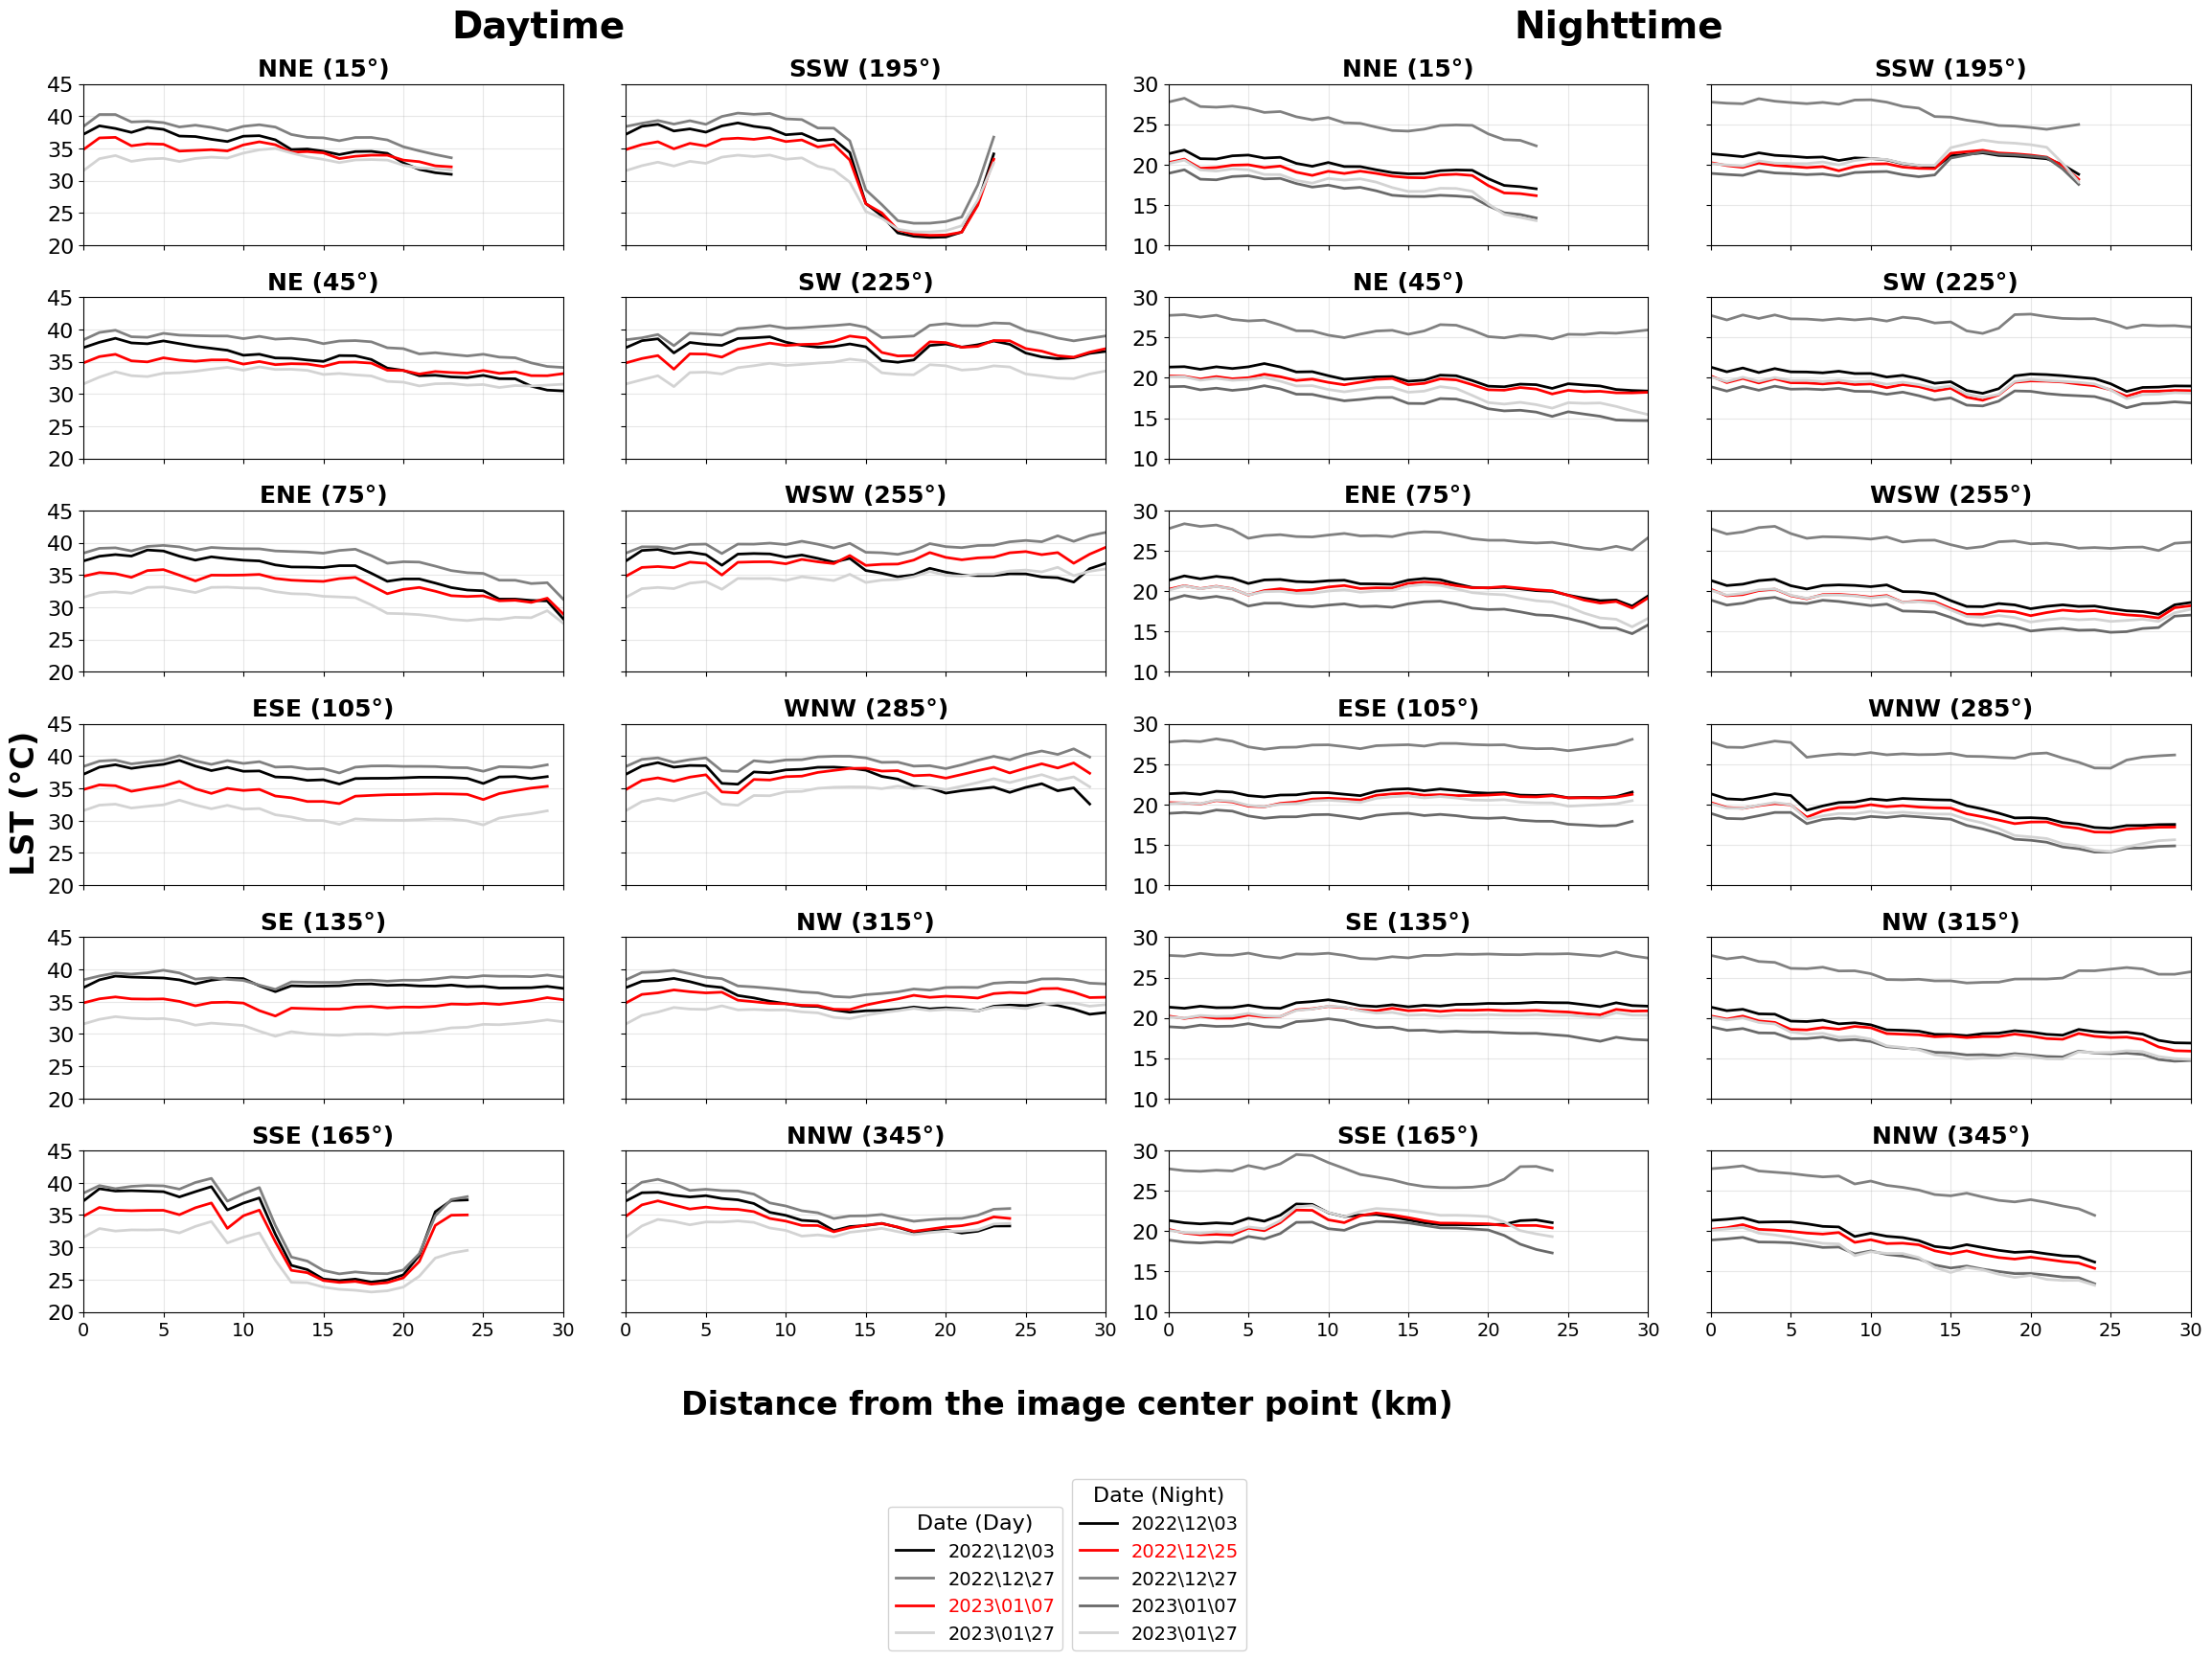

In [153]:
## UPDATE THIS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Convert date format
# -----------------------------
dease_df["date"] = pd.to_datetime(dease_df["date"], dayfirst=True).dt.strftime("%Y\\%m\\%d")

# -----------------------------
# Filter
# -----------------------------
dease_df_day = dease_df[dease_df["temporal"] == "day"]
dease_df_night = dease_df[dease_df["temporal"] == "night"]

# -----------------------------
# Define colours (UPDATED FORMAT)
# -----------------------------
date_colors_day = {
    "2022\\12\\03":  "black",
    "2022\\12\\27": "gray",
    "2023\\01\\07":  "red",
    "2023\\01\\27": "lightgray"
}

date_order_day = ["2022\\12\\03", "2022\\12\\27", "2023\\01\\07", "2023\\01\\27"]

date_colors_night = {
    "2022\\12\\03":  "black",
    "2022\\12\\25": "red",
    "2022\\12\\27": "gray",
    "2023\\01\\07":  "dimgray",
    "2023\\01\\27": "lightgray"
}

date_order_night = ["2022\\12\\03", "2022\\12\\25", "2022\\12\\27", "2023\\01\\07", "2023\\01\\27"]

# -----------------------------
# Bearings
# -----------------------------
bearings = sorted(dease_df["direction"].unique())
bearings_left = [b for b in bearings if b <= 165]
bearings_right = [b for b in bearings if b >= 195]
nrows = max(len(bearings_left), len(bearings_right))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=4,
    figsize=(24, 3 * nrows),
    sharex=True,
    sharey=False
)

if nrows == 1:
    axes = np.array([axes])

# -----------------------------
# Plot
# -----------------------------
def plot_profile(ax, bearing, temporal):
    if temporal == "day":
        df_plot = (
            dease_df_day[dease_df_day["direction"] == bearing]
            [["date", "distance", "mean_lst"]]
            .sort_values(["date", "distance"])
        )
        df_plot["date"] = pd.Categorical(
            df_plot["date"],
            categories=date_order_day,
            ordered=True
        )
        color_map = date_colors_day
    else:
        df_plot = (
            dease_df_night[dease_df_night["direction"] == bearing]
            [["date", "distance", "mean_lst"]]
            .sort_values(["date", "distance"])
        )
        df_plot["date"] = pd.Categorical(
            df_plot["date"],
            categories=date_order_night,
            ordered=True
        )
        color_map = date_colors_night

    for date, g in df_plot.groupby("date", observed=False):
        ax.plot(
            g["distance"],
            g["mean_lst"],
            label=date,
            color=color_map.get(date, "gray"),
            linewidth=2
        )

    compass_labels = {
        15: "NNE",
        45: "NE",
        75: "ENE",
        105: "ESE",
        135: "SE",
        165: "SSE",
        195: "SSW",
        225: "SW",
        255: "WSW",
        285: "WNW",
        315: "NW",
        345: "NNW"
    }
    ax.set_title(f"{compass_labels.get(int(bearing), bearing)} ({bearing}°)", fontsize=18, fontweight="bold")
    ax.grid(alpha=0.3)

for i in range(nrows):
    if i < len(bearings_left):
        plot_profile(axes[i, 0], bearings_left[i], "day")
        plot_profile(axes[i, 2], bearings_left[i], "night")
    else:
        axes[i, 0].axis("off")
        axes[i, 2].axis("off")

    if i < len(bearings_right):
        plot_profile(axes[i, 1], bearings_right[i], "day")
        plot_profile(axes[i, 3], bearings_right[i], "night")
    else:
        axes[i, 1].axis("off")
        axes[i, 3].axis("off")

# -----------------------------
# Axis limits & ticks
# -----------------------------
for row_idx in range(nrows):
    for col_idx, ax in enumerate(axes[row_idx]):
        if not ax.axison:
            continue
        ax.set_xlim(0, 30)
        if col_idx < 2:
            ax.set_ylim(20, 45)
            ax.set_yticks(np.arange(20, 46, 5))
        else:
            ax.set_ylim(10, 30)
            ax.set_yticks(np.arange(10, 31, 5))
        ax.tick_params(axis="y", labelsize=16)
        ax.tick_params(axis="x", labelsize=14)
        if col_idx in [1, 3]:
            ax.tick_params(axis="y", labelleft=False)

fig.text(0.27, 0.96, "Daytime", ha='center', va='top', fontsize=28, fontweight="bold")
fig.text(0.74, 0.96, "Nighttime", ha='center', va='top', fontsize=28, fontweight="bold")

# -----------------------------
# Labels
# -----------------------------
fig.text(0.5, 0.145, "Distance from the image center point (km)", ha='center', fontsize=24, fontweight="bold")

fig.text(0.04, 0.5, "LST (°C)", va='center', rotation='vertical',
         fontsize=24, fontweight="bold")

# -----------------------------
# Legends
# -----------------------------
handles_day, labels_day = [], []
for col in [0, 1]:
    h, l = axes[0, col].get_legend_handles_labels()
    if h:
        handles_day, labels_day = h, l
        break

legend_day = fig.legend(
    handles_day,
    labels_day,
    title="Date (Day)",
    loc="lower center",
    bbox_to_anchor=(0.46, 0.0025),
    ncol=1,
    fontsize=14,
    title_fontsize=16,
    frameon=True,
    framealpha=0.85
)

for text in legend_day.get_texts():
    if "2023\\01\\07" in text.get_text():
        text.set_color("red")

handles_night, labels_night = [], []
for col in [2, 3]:
    h, l = axes[0, col].get_legend_handles_labels()
    if h:
        handles_night, labels_night = h, l
        break

legend_night = fig.legend(
    handles_night,
    labels_night,
    title="Date (Night)",
    loc="lower center",
    bbox_to_anchor=(0.54, 0.0025),
    ncol=1,
    fontsize=14,
    title_fontsize=16,
    frameon=True,
    framealpha=0.85
)

for text in legend_night.get_texts():
    if "2022\\12\\25" in text.get_text():
        text.set_color("red")

# -----------------------------
# Final layout & save
# -----------------------------
fig.subplots_adjust(wspace=0.0, bottom=0.18, top=0.93)
plt.tight_layout(rect=[0.05, 0.18, 1, 0.94])

# --------------------------
# Save figure
# --------------------------
output_path = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\fig8_lst_profile.png"
plt.savefig(output_path, dpi=300)
print("Boxplot saved to:", output_path)

plt.show()


In R, run the code [DEASE day](preprocessing/dease_example_day.txt). 
In R, run the code [DEASE night](preprocessing/dease_example_night.txt). 

Previous versions were
[DEASE day spline and GAM](preprocessing/dease_example_day_spline_gam.txt) and [DEASE night spline and GAM](preprocessing/dease_example_night_spline_gam.txt)


**Gradient-Based Analysis of Radial LST Profiles**

The spatial derivative of Land Surface Temperature (LST) was computed to assess the consistency of spatial temperature gradients:
$$
\frac{\Delta T}{\Delta d}
$$
where the distance increment $\Delta d = 1$ km.

These spatial derivatives were compared between:
- **Predicted LST profiles**, and
- **Base LST profiles**

In [20]:
# Create temp_id from temporal
dease_all_df_metadata_final["temp_id"] = dease_all_df_metadata_final["temporal"].map({
    "day": 1,
    "night": 2
})

# Create date_id (oldest --> newest)
dease_all_df_metadata_final["date"] = pd.to_datetime(dease_all_df_metadata_final["date"], dayfirst=True)
dease_all_df_metadata_final["date_id"] = dease_all_df_metadata_final["date"].rank(method="dense").astype(int)

# Concatenate into gradient_id
dease_all_df_metadata_final["gradient_id"] = (
    dease_all_df_metadata_final["temp_id"].astype(str) + "_" +
    dease_all_df_metadata_final["date_id"].astype(str) + "_" +
    dease_all_df_metadata_final["direction"].astype(str) 
)

# Buffer id (no date_id because we want to compare buffers across dates for the same direction and temporal category)
dease_all_df_metadata_final["buffer_id"] = (
    dease_all_df_metadata_final["temp_id"].astype(str) + "_" +
    dease_all_df_metadata_final["direction"].astype(str) + "_" +
    dease_all_df_metadata_final["distance"].astype(str)
)

# Sort by 1. temp-id, 2. date-id, 3. direction, 4. distance
dease_all_df_metadata_final = dease_all_df_metadata_final.sort_values(["temp_id", "date_id", "direction", "distance"]).reset_index(drop=True)

# Display the first 30 rows of the DEASE delta dataset
dease_all_df_metadata_final.head(30)


,temporal,date,id,mean_lst,distance,direction,area,use,temp_id,date_id,gradient_id,buffer_id
0,day,2022-12-03,361,37.179070,0,15,0.900000,prediction,1,1,1_1_15,1_15_0
1,day,2022-12-03,40,38.494224,1,15,26.149934,prediction,1,1,1_1_15,1_15_1
2,day,2022-12-03,46,38.085532,2,15,78.506351,prediction,1,1,1_1_15,1_15_2
3,day,2022-12-03,59,37.480061,3,15,130.871230,prediction,1,1,1_1_15,1_15_3
4,day,2022-12-03,69,38.238366,4,15,183.246919,prediction,1,1,1_1_15,1_15_4
5,day,2022-12-03,81,37.946716,5,15,235.597027,prediction,1,1,1_1_15,1_15_5
6,day,2022-12-03,92,36.910628,6,15,287.960623,prediction,1,1,1_1_15,1_15_6
7,day,2022-12-03,103,36.835274,7,15,340.284752,prediction,1,1,1_1_15,1_15_7
8,day,2022-12-03,114,36.410098,8,15,392.695837,prediction,1,1,1_1_15,1_15_8
9,day,2022-12-03,125,36.063703,9,15,445.061890,prediction,1,1,1_1_15,1_15_9


In [21]:
# Retrieve delta T
dease_all_df_metadata_final["delta_T"] = (
    dease_all_df_metadata_final
    .groupby(["temp_id", "date_id", "direction"])["mean_lst"]
    .diff()
)

# Display the first 30 rows of the DEASE delta dataset
dease_all_df_metadata_final.head(30)

,temporal,date,id,mean_lst,distance,direction,area,use,temp_id,date_id,gradient_id,buffer_id,delta_T
0,day,2022-12-03,361,37.179070,0,15,0.900000,prediction,1,1,1_1_15,1_15_0,NaN
1,day,2022-12-03,40,38.494224,1,15,26.149934,prediction,1,1,1_1_15,1_15_1,1.315154
2,day,2022-12-03,46,38.085532,2,15,78.506351,prediction,1,1,1_1_15,1_15_2,-0.408692
3,day,2022-12-03,59,37.480061,3,15,130.871230,prediction,1,1,1_1_15,1_15_3,-0.605471
4,day,2022-12-03,69,38.238366,4,15,183.246919,prediction,1,1,1_1_15,1_15_4,0.758306
5,day,2022-12-03,81,37.946716,5,15,235.597027,prediction,1,1,1_1_15,1_15_5,-0.291650
6,day,2022-12-03,92,36.910628,6,15,287.960623,prediction,1,1,1_1_15,1_15_6,-1.036089
7,day,2022-12-03,103,36.835274,7,15,340.284752,prediction,1,1,1_1_15,1_15_7,-0.075353
8,day,2022-12-03,114,36.410098,8,15,392.695837,prediction,1,1,1_1_15,1_15_8,-0.425177
9,day,2022-12-03,125,36.063703,9,15,445.061890,prediction,1,1,1_1_15,1_15_9,-0.346395


In [22]:
# Remove delta_T with NaN 
dease_delta = (
    dease_all_df_metadata_final
    .dropna(subset=["delta_T"])
    .sort_values(["temp_id", "date_id", "direction", "distance"])
    .reset_index(drop=True)
)

# Create dease_delta_base (filter use == "base")
dease_delta_base = dease_delta[dease_delta["use"] == "base"].copy()

# Rename delta_T --> delta_T_base
dease_delta_base = dease_delta_base.rename(columns={"delta_T": "delta_T_base", "mean_lst": "mean_lst_base"})

# Join back to the main delta dataset
dease_delta = dease_delta.merge(dease_delta_base[["buffer_id", "delta_T_base", "mean_lst_base"]], on="buffer_id", how="left")

# Filter an example of buffer_id with both base and prediction rows (example: buffer_id == "1_255_1" --> day, bearing 255, distance 1km from the centre point)
dease_delta_example = dease_delta[dease_delta["buffer_id"] == "1_255_1"]

# Display an example of buffer_id with both base and prediction rows 
dease_delta_example.head()

,temporal,date,id,mean_lst,distance,direction,area,use,temp_id,date_id,gradient_id,buffer_id,delta_T,delta_T_base,mean_lst_base
219,day,2022-12-03,36,38.805411,1,255,26.149313,prediction,1,1,1_1_255,1_255_1,1.626341,1.367811,36.181066
551,day,2022-12-27,36,39.375154,1,255,26.149313,prediction,1,3,1_3_255,1_255_1,0.980933,1.367811,36.181066
883,day,2023-01-07,36,36.181066,1,255,26.149313,base,1,4,1_4_255,1_255_1,1.367811,1.367811,36.181066
1215,day,2023-01-27,36,32.891874,1,255,26.149313,prediction,1,5,1_5_255,1_255_1,1.344148,1.367811,36.181066


In [23]:
# Remove all rows where use == "base"
dease_delta_filtered = dease_delta[
    dease_delta["use"] != "base"
].copy()

# Filter for daytime only
dease_delta_day = dease_delta_filtered[dease_delta_filtered["temporal"] == "day"].copy()

# Filter for nighttime only
dease_delta_night = dease_delta_filtered[dease_delta_filtered["temporal"] == "night"].copy()

# Display the first 30 rows of the DEASE delta dataset
dease_delta.head(30)

# Save dease delta CSV
out_csv_delta = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\dease_delta.csv"
dease_delta.to_csv(out_csv_delta, index=False)

In [24]:
# Paired t-test for daytime
from scipy import stats

t_stat, p_value = stats.ttest_rel(
    dease_delta_day["delta_T"],
    dease_delta_day["delta_T_base"],
    nan_policy="omit"  # ignores NaNs
)

print("t-statistic:", t_stat)
print("p-value:", p_value)


t-statistic: -4.207373685789249
p-value: 2.8168669281776683e-05


### 4.3.3 Compute MAE, RMSE, Pearson correlation by date and direction
- Global
- By date → weather / atmospheric variability
- By direction → spatial anisotropy / urban morphology

#### a. Daytime

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# ---------------------------
# Example: dease_delta_day already filtered for temporal == "day"
# Columns: distance, delta_T, delta_T_base
# ---------------------------

# Compute error metrics (absolute difference)
mae = (dease_delta_day["delta_T"] - dease_delta_day["delta_T_base"]).abs().mean()
rmse = np.sqrt(((dease_delta_day["delta_T"] - dease_delta_day["delta_T_base"])**2).mean())
corr, _ = pearsonr(dease_delta_day["delta_T"], dease_delta_day["delta_T_base"])

print(f"MAE: {mae:.3f} °C")
print(f"RMSE: {rmse:.3f} °C")
print(f"Pearson correlation: {corr:.3f}")


MAE: 0.223 °C
RMSE: 0.313 °C
Pearson correlation: 0.958


In [26]:
from IPython.display import display

# check the number of rows per date in dease_delta_day
dease_delta_day.groupby("date").size()
display(dease_delta_day.groupby("date").size())

# Metrics by date, direction, and both date and direction
def compute_metrics(dease_delta_day):
    diff = dease_delta_day["delta_T"] - dease_delta_day["delta_T_base"]
    
    mae = diff.abs().mean()
    rmse = np.sqrt((diff**2).mean())
    
    # Guard against constant values
    if dease_delta_day["delta_T"].nunique() > 1 and dease_delta_day["delta_T_base"].nunique() > 1:
        corr, _ = pearsonr(dease_delta_day["delta_T"], dease_delta_day["delta_T_base"])
    else:
        corr = np.nan
        
    return pd.Series({
        "MAE": mae,
        "RMSE": rmse,
        "Pearson_r": corr
    })

day_metrics_by_date = (
    dease_delta_day
    .groupby("date")
    .apply(compute_metrics)
    .reset_index()
)

day_metrics_by_date
day_metrics_by_direction = (
    dease_delta_day
    .groupby("direction")
    .apply(compute_metrics)
    .reset_index()
)

day_metrics_by_date_direction = (
    dease_delta_day
    .groupby(["date", "direction"])
    .apply(compute_metrics)
    .reset_index()
)


display(day_metrics_by_date)
display(day_metrics_by_direction)
display(day_metrics_by_date_direction)

out_csv_metrics_date_direction = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\day_metrics_by_date_direction.csv"
day_metrics_by_date_direction.to_csv(out_csv_metrics_date_direction, index=False)

date
2022-12-03    332
2022-12-27    332
2023-01-27    332
dtype: int64

,date,MAE,RMSE,Pearson_r
0,2022-12-03,0.240357,0.312182,0.967826
1,2022-12-27,0.207945,0.271704,0.969392
2,2023-01-27,0.221971,0.349762,0.962265


,direction,MAE,RMSE,Pearson_r
0,15,0.264661,0.331742,0.878837
1,45,0.195739,0.246655,0.874542
2,75,0.224897,0.284336,0.918822
3,105,0.172112,0.217720,0.927374
4,135,0.134621,0.177907,0.916715
5,165,0.335599,0.532121,0.969174
6,195,0.332301,0.491477,0.979484
7,225,0.247991,0.299761,0.958959
8,255,0.258475,0.335873,0.931258
9,285,0.204288,0.270846,0.956206


,date,direction,MAE,RMSE,Pearson_r
0,2022-12-03,15,0.307907,0.380184,0.867068
1,2022-12-03,45,0.235376,0.279979,0.899140
2,2022-12-03,75,0.208906,0.266833,0.939635
3,2022-12-03,105,0.180634,0.244040,0.907455
4,2022-12-03,135,0.140393,0.184138,0.916200
5,2022-12-03,165,0.271635,0.396707,0.990395
6,2022-12-03,195,0.285695,0.383538,0.993091
7,2022-12-03,225,0.300235,0.338296,0.942063
8,2022-12-03,255,0.313139,0.389734,0.916639
9,2022-12-03,285,0.262123,0.326767,0.974883


In [27]:
# Save metrics by date to CSV
day_table_date = (
    day_metrics_by_date
    .assign(
        MAE=lambda d: d["MAE"].round(3),
        RMSE=lambda d: d["RMSE"].round(3),
        Pearson_r=lambda d: d["Pearson_r"].round(3)
    )
    .rename(columns={
        "date": "Date",
        "Pearson_r": "r"
    })
    [["Date", "MAE", "RMSE", "r"]]
)

day_table_date

# Save metrics by direction to CSV
day_table_direction = (
    day_metrics_by_direction
    .assign(
        MAE=lambda d: d["MAE"].round(3),
        RMSE=lambda d: d["RMSE"].round(3),
        Pearson_r=lambda d: d["Pearson_r"].round(3)
    )
    .rename(columns={
        "direction": "Direction",
        "Pearson_r": "r"
    })
    [["Direction", "MAE", "RMSE", "r"]]
)

day_table_direction

out_csv_metrics_date = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\day_metrics_by_date.csv"
day_table_date.to_csv(out_csv_metrics_date, index=False)

out_csv_metrics_direction = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\day_metrics_by_direction.csv"
day_table_direction.to_csv(out_csv_metrics_direction, index=False)



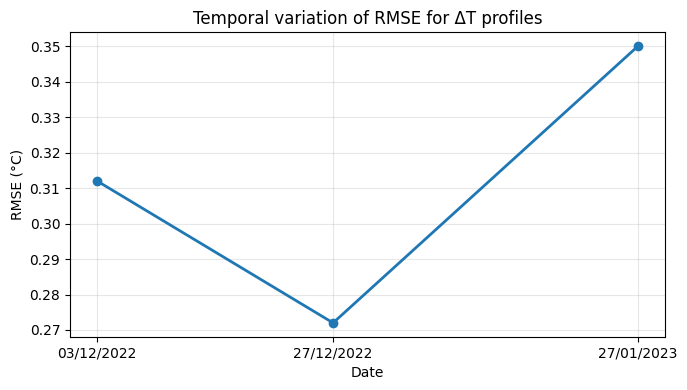

In [28]:
# Plot RMSE vs date
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import pandas as pd


# Ensure Date column is datetime
day_table_date['Date'] = pd.to_datetime(day_table_date['Date'])

plt.figure(figsize=(7, 4))

plt.plot(
    day_table_date["Date"],
    day_table_date["RMSE"],
    marker="o",
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("RMSE (°C)")
plt.title("Temporal variation of RMSE for ΔT profiles")

# Use only your dates as ticks
plt.xticks(day_table_date['Date'], day_table_date['Date'].dt.strftime('%d/%m/%Y'), rotation=0)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


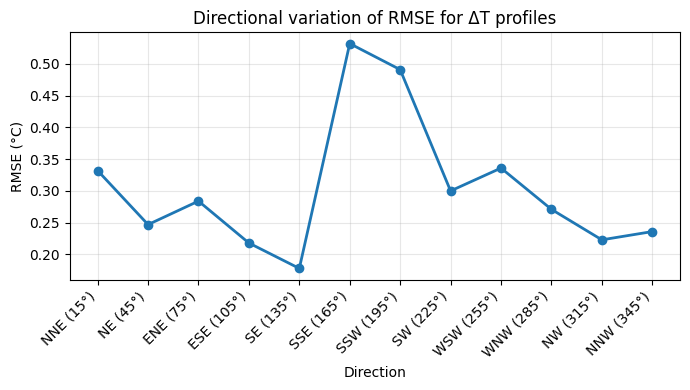

In [29]:
# Plot RMSE vs direction
import matplotlib.pyplot as plt

direction_labels = {
    15:  "NNE (15°)",
    45:  "NE (45°)",
    75:  "ENE (75°)",
    105: "ESE (105°)",
    135: "SE (135°)",
    165: "SSE (165°)",
    195: "SSW (195°)",
    225: "SW (225°)",
    255: "WSW (255°)",
    285: "WNW (285°)",
    315: "NW (315°)",
    345: "NNW (345°)"
}

# Sort directions for clean plotting
plot_df = day_table_direction.sort_values("Direction")

plt.figure(figsize=(7, 4))

plt.plot(
    plot_df["Direction"],
    plot_df["RMSE"],
    marker="o",
    linewidth=2
)

# Custom ticks
plt.xticks(
    ticks=plot_df["Direction"],
    labels=[direction_labels[d] for d in plot_df["Direction"]],
    rotation=45,
    ha="right"
)

plt.xlabel("Direction")
plt.ylabel("RMSE (°C)")
plt.title("Directional variation of RMSE for ΔT profiles")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


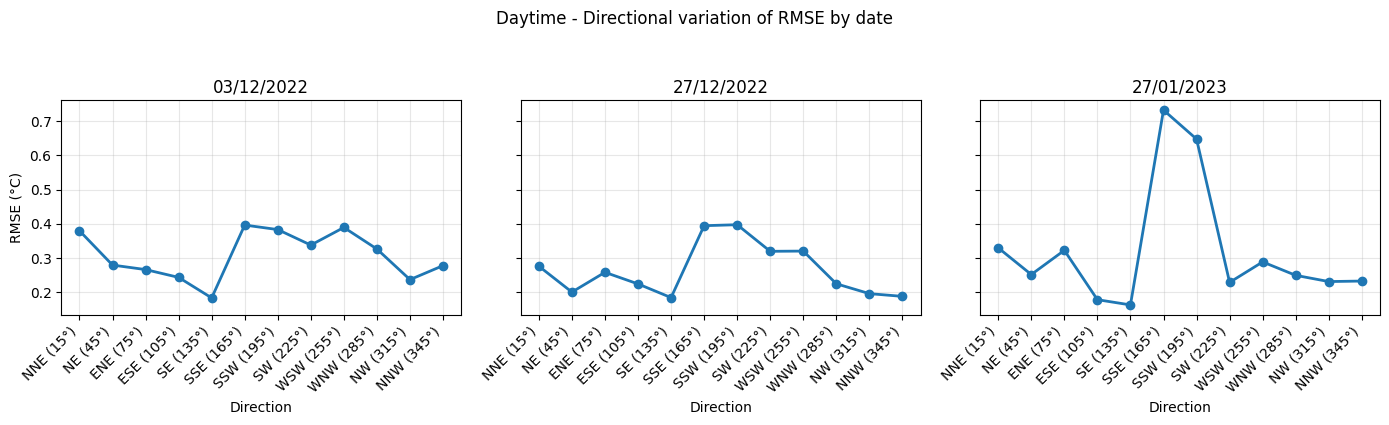

In [30]:
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import pandas as pd
# Plot by date and direction
# Recompute the metrics by date and direction
day_metrics_by_date_direction = (
    dease_delta_day
    .groupby(["date", "direction"])
    .apply(compute_metrics)
    .reset_index()
)


# Direction labels for plotting
direction_labels = {
    15:  "NNE (15°)",
    45:  "NE (45°)",
    75:  "ENE (75°)",
    105: "ESE (105°)",
    135: "SE (135°)",
    165: "SSE (165°)",
    195: "SSW (195°)",
    225: "SW (225°)",
    255: "WSW (255°)",
    285: "WNW (285°)",
    315: "NW (315°)",
    345: "NNW (345°)"
}


# Plot RMSE by date and direction
dates = sorted(day_metrics_by_date_direction["date"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(dates),
    figsize=(14, 4),
    sharey=True
)

for ax, date in zip(axes, dates):
    df_plot = (
        day_metrics_by_date_direction
        [day_metrics_by_date_direction["date"] == date]
        .sort_values("direction")
    )
    
    ax.plot(
        df_plot["direction"],
        df_plot["RMSE"],
        marker="o",
        linewidth=2
    )
    
    # Format date as DD/MM/YYYY
    ax.set_title(pd.Timestamp(date).strftime('%d/%m/%Y'))
    
    ax.set_xlabel("Direction")
    ax.set_xticks(df_plot["direction"])
    ax.set_xticklabels(
        [direction_labels[d] for d in df_plot["direction"]],
        rotation=45,
        ha="right"
    )
    
    ax.grid(True, alpha=0.3)


axes[0].set_ylabel("RMSE (°C)")

plt.suptitle("Daytime - Directional variation of RMSE by date", y=1.05)
plt.tight_layout()

# Save the plot locally (PNG, PDF, etc.)
plt.savefig("day_RMSE_vs_date_and_direction.png", dpi=300)

plt.show()


Boxplot saved to: C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\fig10_a_polar_RMSE.png


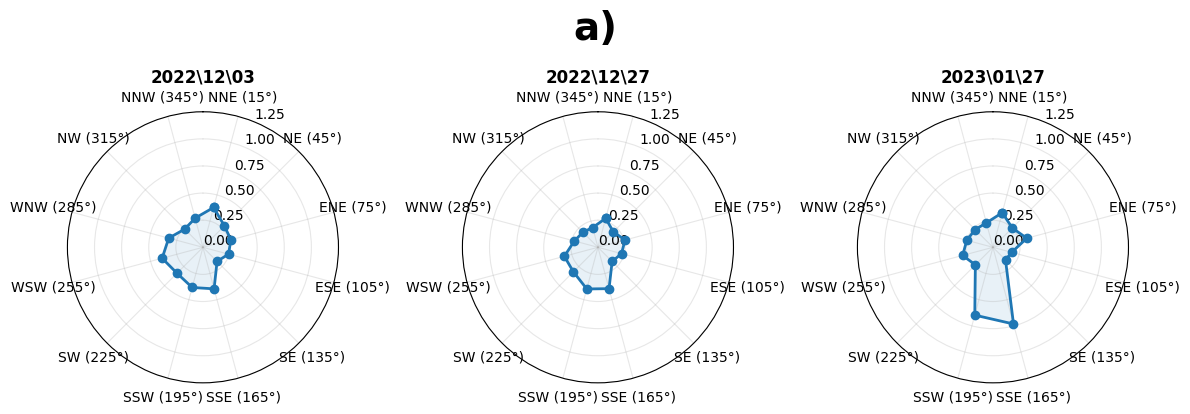

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Get sorted unique dates
dates = sorted(day_metrics_by_date_direction["date"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(dates),
    subplot_kw={'projection': 'polar'},
    figsize=(4 * len(dates), 4)
)

# If only one date, axes is not iterable
if len(dates) == 1:
    axes = [axes]

for ax, date in zip(axes, dates):
    
    df_plot = (
        day_metrics_by_date_direction
        [day_metrics_by_date_direction["date"] == date]
        .sort_values("direction")
    )
    
    theta = np.deg2rad(df_plot["direction"].values)
    values = df_plot["RMSE"].values
    
    # Close circle
    theta = np.append(theta, theta[0])
    values = np.append(values, values[0])
    
    ax.plot(theta, values, marker="o", linewidth=2)
    ax.fill(theta, values, alpha=0.1)
    
    # ✅ Geographic orientation
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    
    # ✅ Fixed radial limits
    ax.set_ylim(0, 1.25)
    ax.set_yticks(np.arange(0, 1.26, 0.25))
    
    ax.set_title(pd.Timestamp(date).strftime('%Y\%m\%d'), fontweight='bold')

    angles = df_plot["direction"].values
    ax.set_xticks(np.deg2rad(angles))
    ax.set_xticklabels([direction_labels[d] for d in angles])

    # Set direction labels
    ax.set_xticks(np.deg2rad(df_plot["direction"]))
    ax.set_xticklabels(
        [direction_labels[d] for d in df_plot["direction"]]
    )
    
    ax.grid(True, alpha=0.3)


plt.suptitle("a)", y=1, fontsize=28, fontweight="bold")
plt.tight_layout()

# --------------------------
# Save figure
# --------------------------
output_path = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\fig10_a_polar_RMSE.png"
plt.savefig(output_path, dpi=300)
print("Boxplot saved to:", output_path)

plt.show()


Boxplot saved to: C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\fig10_b_polar_MAE.png


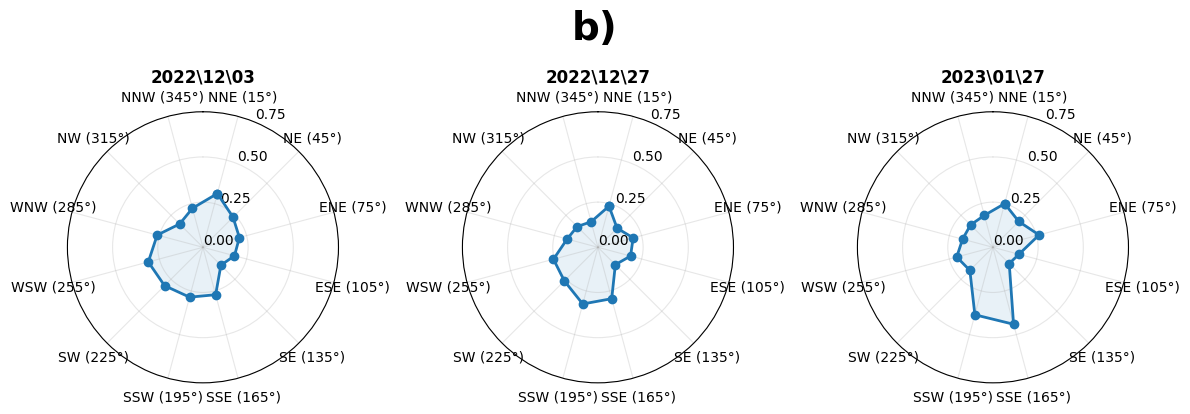

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Get sorted unique dates
dates = sorted(day_metrics_by_date_direction["date"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(dates),
    subplot_kw={'projection': 'polar'},
    figsize=(4 * len(dates), 4)
)

# If only one date, axes is not iterable
if len(dates) == 1:
    axes = [axes]

for ax, date in zip(axes, dates):
    
    df_plot = (
        day_metrics_by_date_direction
        [day_metrics_by_date_direction["date"] == date]
        .sort_values("direction")
    )
    
    theta = np.deg2rad(df_plot["direction"].values)
    values = df_plot["MAE"].values
    
    # Close circle
    theta = np.append(theta, theta[0])
    values = np.append(values, values[0])
    
    ax.plot(theta, values, marker="o", linewidth=2)
    ax.fill(theta, values, alpha=0.1)
    
    # ✅ Geographic orientation
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    
    # ✅ Fixed radial limits
    ax.set_ylim(0, 0.75)
    ax.set_yticks(np.arange(0, 0.76, 0.25))
    
    ax.set_title(pd.Timestamp(date).strftime('%Y\%m\%d'), fontweight='bold')

    angles = df_plot["direction"].values
    ax.set_xticks(np.deg2rad(angles))
    ax.set_xticklabels([direction_labels[d] for d in angles])

    # Set direction labels
    ax.set_xticks(np.deg2rad(df_plot["direction"]))
    ax.set_xticklabels(
        [direction_labels[d] for d in df_plot["direction"]]
    )
    
    ax.grid(True, alpha=0.3)

plt.suptitle("b)", y=1, fontsize=28, fontweight="bold")
plt.tight_layout()

# --------------------------
# Save figure
# --------------------------
output_path = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\fig10_b_polar_MAE.png"
plt.savefig(output_path, dpi=300)
print("Boxplot saved to:", output_path)

plt.show()


Boxplot saved to: C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\fig10_b_polar_Pearson_r.png


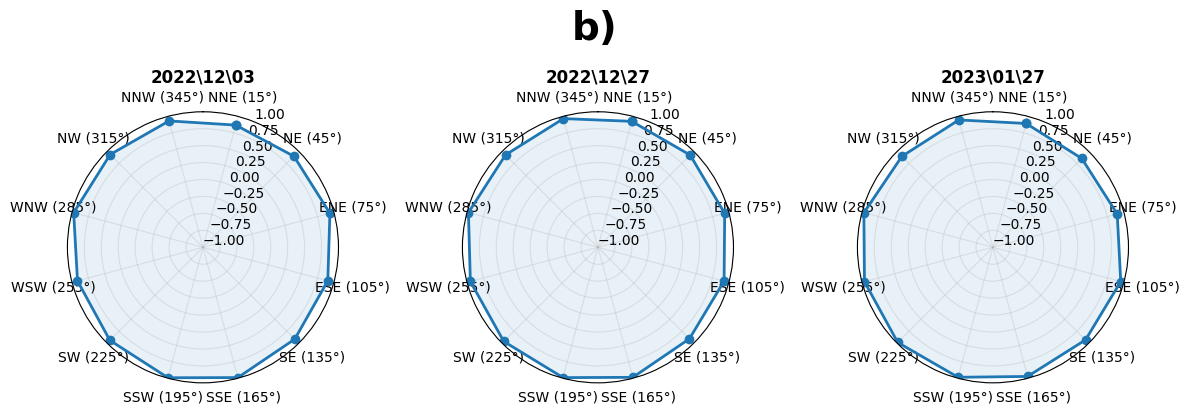

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Get sorted unique dates
dates = sorted(day_metrics_by_date_direction["date"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(dates),
    subplot_kw={'projection': 'polar'},
    figsize=(4 * len(dates), 4)
)

# If only one date, axes is not iterable
if len(dates) == 1:
    axes = [axes]

for ax, date in zip(axes, dates):
    
    df_plot = (
        day_metrics_by_date_direction
        [day_metrics_by_date_direction["date"] == date]
        .sort_values("direction")
    )
    
    theta = np.deg2rad(df_plot["direction"].values)
    values = df_plot["Pearson_r"].values
    
    # Close circle
    theta = np.append(theta, theta[0])
    values = np.append(values, values[0])
    
    ax.plot(theta, values, marker="o", linewidth=2)
    ax.fill(theta, values, alpha=0.1)
    
    # ✅ Geographic orientation
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    
    # ✅ Fixed radial limits
    ax.set_ylim(-1, 1)
    ax.set_yticks(np.arange(-1, 1.01, 0.25))
    
    ax.set_title(pd.Timestamp(date).strftime('%Y\%m\%d'), fontweight='bold')

    angles = df_plot["direction"].values
    ax.set_xticks(np.deg2rad(angles))
    ax.set_xticklabels([direction_labels[d] for d in angles])

    # Set direction labels
    ax.set_xticks(np.deg2rad(df_plot["direction"]))
    ax.set_xticklabels(
        [direction_labels[d] for d in df_plot["direction"]]
    )
    
    ax.grid(True, alpha=0.3)

plt.suptitle("b)", y=1, fontsize=28, fontweight="bold")
plt.tight_layout()

# --------------------------
# Save figure
# --------------------------
output_path = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\fig10_b_polar_Pearson_r.png"
plt.savefig(output_path, dpi=300)
print("Boxplot saved to:", output_path)

plt.show()

#### b. Nighttime

In [34]:
# Compute error metrics (absolute difference)
mae = (dease_delta_night["delta_T"] - dease_delta_night["delta_T_base"]).abs().mean()
rmse = np.sqrt(((dease_delta_night["delta_T"] - dease_delta_night["delta_T_base"])**2).mean())
corr, _ = pearsonr(dease_delta_night["delta_T"], dease_delta_night["delta_T_base"])

print(f"MAE: {mae:.3f} °C")
print(f"RMSE: {rmse:.3f} °C")
print(f"Pearson correlation: {corr:.3f}")


MAE: 0.127 °C
RMSE: 0.198 °C
Pearson correlation: 0.899


In [35]:
from IPython.display import display

# check the number of rows per date in dease_delta_night
dease_delta_night.groupby("date").size()
display(dease_delta_night.groupby("date").size())

# Metrics by date, direction, and both date and direction
def compute_metrics(dease_delta_night):
    diff = dease_delta_night["delta_T"] - dease_delta_night["delta_T_base"]
    
    mae = diff.abs().mean()
    rmse = np.sqrt((diff**2).mean())
    
    # Guard against constant values
    if dease_delta_night["delta_T"].nunique() > 1 and dease_delta_night["delta_T_base"].nunique() > 1:
        corr, _ = pearsonr(dease_delta_night["delta_T"], dease_delta_night["delta_T_base"])
    else:
        corr = np.nan
        
    return pd.Series({
        "MAE": mae,
        "RMSE": rmse,
        "Pearson_r": corr
    })

night_metrics_by_date = (
    dease_delta_night
    .groupby("date")
    .apply(compute_metrics)
    .reset_index()
)

night_metrics_by_date
night_metrics_by_direction = (
    dease_delta_night
    .groupby("direction")
    .apply(compute_metrics)
    .reset_index()
)

night_metrics_by_date_direction = (
    dease_delta_night
    .groupby(["date", "direction"])
    .apply(compute_metrics)
    .reset_index()
)


display(night_metrics_by_date)
display(night_metrics_by_direction)
display(night_metrics_by_date_direction)

out_csv_metrics_date_direction = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\night_metrics_by_date_direction.csv"
night_metrics_by_date_direction.to_csv(out_csv_metrics_date_direction, index=False)

date
2022-12-03    332
2022-12-27    332
2023-01-07    332
2023-01-27    332
dtype: int64

,date,MAE,RMSE,Pearson_r
0,2022-12-03,0.086872,0.120533,0.963356
1,2022-12-27,0.175866,0.291052,0.769622
2,2023-01-07,0.120710,0.160787,0.934621
3,2023-01-27,0.122687,0.175907,0.936098


,direction,MAE,RMSE,Pearson_r
0,15,0.128279,0.164385,0.947366
1,45,0.122686,0.156456,0.916684
2,75,0.115142,0.142188,0.950281
3,105,0.097240,0.121442,0.891512
4,135,0.090164,0.114522,0.915274
5,165,0.213098,0.361001,0.787981
6,195,0.203096,0.399139,0.796116
7,225,0.091771,0.119680,0.974211
8,255,0.117430,0.158200,0.941285
9,285,0.124544,0.173506,0.929726


,date,direction,MAE,RMSE,Pearson_r
0,2022-12-03,15,0.078054,0.109551,0.973843
1,2022-12-03,45,0.095050,0.114439,0.950817
2,2022-12-03,75,0.085147,0.104601,0.972953
3,2022-12-03,105,0.081998,0.104068,0.914675
4,2022-12-03,135,0.080424,0.092257,0.942059
5,2022-12-03,165,0.137512,0.205077,0.934047
6,2022-12-03,195,0.132587,0.194304,0.974527
7,2022-12-03,225,0.065585,0.086915,0.986878
8,2022-12-03,255,0.056760,0.074137,0.989943
9,2022-12-03,285,0.072159,0.102021,0.977673


In [36]:
# Save metrics by date to CSV
night_table_date = (
    night_metrics_by_date
    .assign(
        MAE=lambda d: d["MAE"].round(3),
        RMSE=lambda d: d["RMSE"].round(3),
        Pearson_r=lambda d: d["Pearson_r"].round(3)
    )
    .rename(columns={
        "date": "Date",
        "Pearson_r": "r"
    })
    [["Date", "MAE", "RMSE", "r"]]
)

night_table_date

# Save metrics by direction to CSV
night_table_direction = (
    night_metrics_by_direction
    .assign(
        MAE=lambda d: d["MAE"].round(3),
        RMSE=lambda d: d["RMSE"].round(3),
        Pearson_r=lambda d: d["Pearson_r"].round(3)
    )
    .rename(columns={
        "direction": "Direction",
        "Pearson_r": "r"
    })
    [["Direction", "MAE", "RMSE", "r"]]
)

night_table_direction

out_csv_metrics_date = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\night_metrics_by_date.csv"
night_table_date.to_csv(out_csv_metrics_date, index=False)

out_csv_metrics_direction = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\night_metrics_by_direction.csv"
night_table_direction.to_csv(out_csv_metrics_direction, index=False)


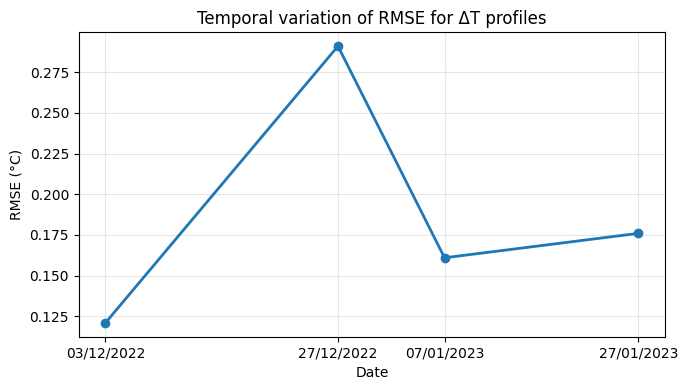

In [37]:
# Plot RMSE vs date
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import pandas as pd


# Ensure Date column is datetime
night_table_date['Date'] = pd.to_datetime(night_table_date['Date'])

plt.figure(figsize=(7, 4))

plt.plot(
    night_table_date["Date"],
    night_table_date["RMSE"],
    marker="o",
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("RMSE (°C)")
plt.title("Temporal variation of RMSE for ΔT profiles")

# Use only your dates as ticks
plt.xticks(night_table_date['Date'], night_table_date['Date'].dt.strftime('%d/%m/%Y'), rotation=0)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

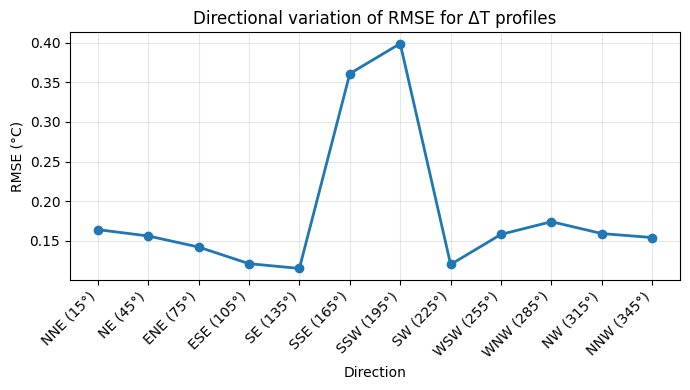

In [38]:
# Plot RMSE vs direction
import matplotlib.pyplot as plt

direction_labels = {
    15:  "NNE (15°)",
    45:  "NE (45°)",
    75:  "ENE (75°)",
    105: "ESE (105°)",
    135: "SE (135°)",
    165: "SSE (165°)",
    195: "SSW (195°)",
    225: "SW (225°)",
    255: "WSW (255°)",
    285: "WNW (285°)",
    315: "NW (315°)",
    345: "NNW (345°)"
}

# Sort directions for clean plotting
plot_df = night_table_direction.sort_values("Direction")

plt.figure(figsize=(7, 4))

plt.plot(
    plot_df["Direction"],
    plot_df["RMSE"],
    marker="o",
    linewidth=2
)

# Custom ticks
plt.xticks(
    ticks=plot_df["Direction"],
    labels=[direction_labels[d] for d in plot_df["Direction"]],
    rotation=45,
    ha="right"
)

plt.xlabel("Direction")
plt.ylabel("RMSE (°C)")
plt.title("Directional variation of RMSE for ΔT profiles")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


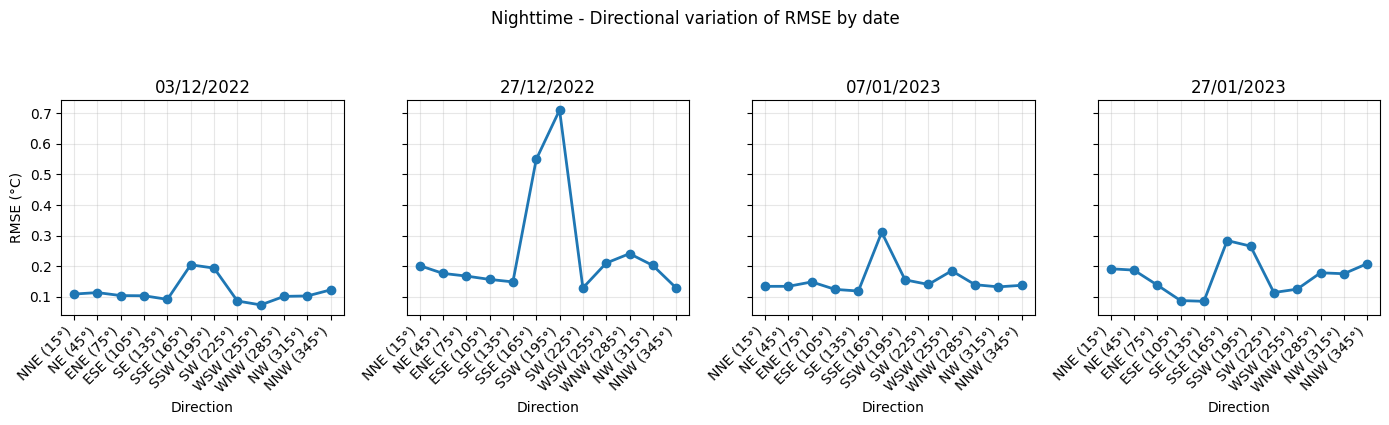

In [39]:
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import pandas as pd
# Plot by date and direction
# Recompute the metrics by date and direction
night_metrics_by_date_direction = (
    dease_delta_night
    .groupby(["date", "direction"])
    .apply(compute_metrics)
    .reset_index()
)


# Direction labels for plotting
direction_labels = {
    15:  "NNE (15°)",
    45:  "NE (45°)",
    75:  "ENE (75°)",
    105: "ESE (105°)",
    135: "SE (135°)",
    165: "SSE (165°)",
    195: "SSW (195°)",
    225: "SW (225°)",
    255: "WSW (255°)",
    285: "WNW (285°)",
    315: "NW (315°)",
    345: "NNW (345°)"
}


# Plot RMSE by date and direction
dates = sorted(night_metrics_by_date_direction["date"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(dates),
    figsize=(14, 4),
    sharey=True
)

for ax, date in zip(axes, dates):
    df_plot = (
        night_metrics_by_date_direction
        [night_metrics_by_date_direction["date"] == date]
        .sort_values("direction")
    )
    
    ax.plot(
        df_plot["direction"],
        df_plot["RMSE"],
        marker="o",
        linewidth=2
    )
    
    # Format date as DD/MM/YYYY
    ax.set_title(pd.Timestamp(date).strftime('%d/%m/%Y'))
    
    ax.set_xlabel("Direction")
    ax.set_xticks(df_plot["direction"])
    ax.set_xticklabels(
        [direction_labels[d] for d in df_plot["direction"]],
        rotation=45,
        ha="right"
    )
    
    ax.grid(True, alpha=0.3)


axes[0].set_ylabel("RMSE (°C)")

plt.suptitle("Nighttime - Directional variation of RMSE by date", y=1.05)
plt.tight_layout()

# Save the plot locally (PNG, PDF, etc.)
plt.savefig("night_RMSE_vs_date_and_direction.png", dpi=300)

plt.show()

Boxplot saved to: C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\fig10_c_night_polar_RMSE.png


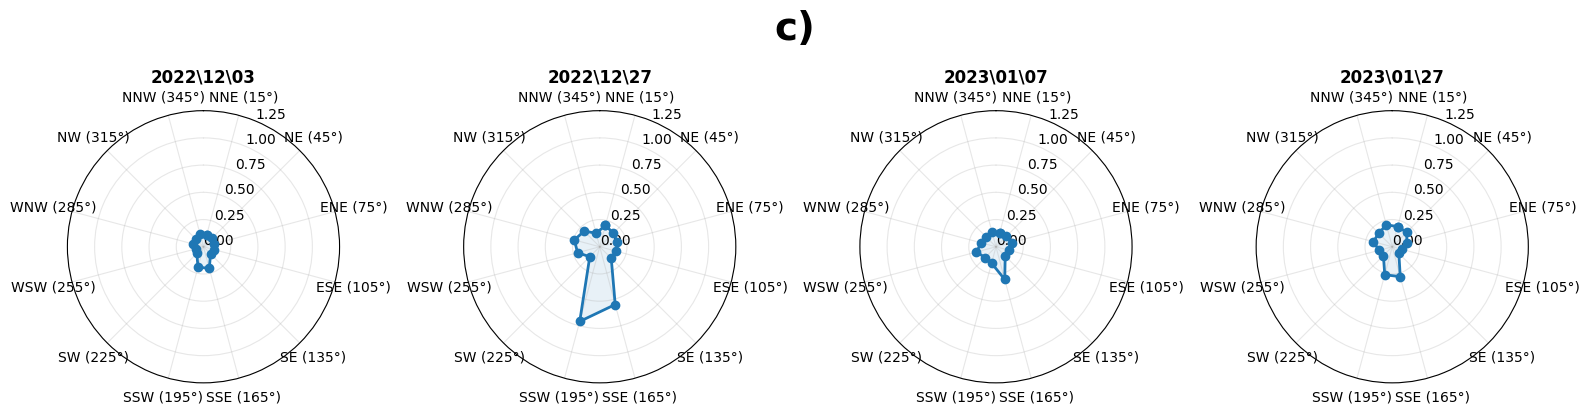

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Get sorted unique dates
dates = sorted(night_metrics_by_date_direction["date"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(dates),
    subplot_kw={'projection': 'polar'},
    figsize=(4 * len(dates), 4)
)

# If only one date, axes is not iterable
if len(dates) == 1:
    axes = [axes]

for ax, date in zip(axes, dates):
    
    df_plot = (
        night_metrics_by_date_direction
        [night_metrics_by_date_direction["date"] == date]
        .sort_values("direction")
    )
    
    theta = np.deg2rad(df_plot["direction"].values)
    values = df_plot["RMSE"].values
    
    # Close circle
    theta = np.append(theta, theta[0])
    values = np.append(values, values[0])
    
    ax.plot(theta, values, marker="o", linewidth=2)
    ax.fill(theta, values, alpha=0.1)
    
    # ✅ Geographic orientation
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    
    # ✅ Fixed radial limits
    ax.set_ylim(0, 1.25)
    ax.set_yticks(np.arange(0, 1.26, 0.25))
    
    ax.set_title(pd.Timestamp(date).strftime('%Y\%m\%d'), fontweight='bold')
    
    ax.set_xticks(np.deg2rad(df_plot["direction"]))
    ax.set_xticklabels(
        [direction_labels[d] for d in df_plot["direction"]]
    )
    
    ax.grid(True, alpha=0.3)

plt.suptitle("c)", y=1, fontsize=28, fontweight="bold")
plt.tight_layout()

# --------------------------
# Save figure
# --------------------------
output_path = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\fig10_c_night_polar_RMSE.png"
plt.savefig(output_path, dpi=300)
print("Boxplot saved to:", output_path)

plt.show()


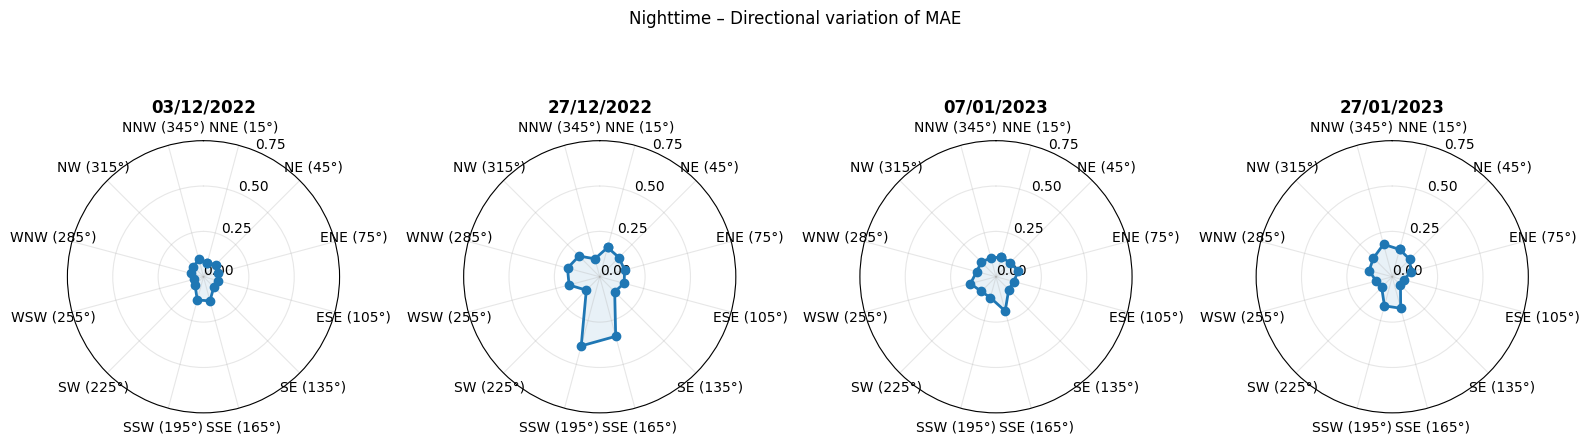

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Get sorted unique dates
dates = sorted(night_metrics_by_date_direction["date"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(dates),
    subplot_kw={'projection': 'polar'},
    figsize=(4 * len(dates), 4)
)

# If only one date, axes is not iterable
if len(dates) == 1:
    axes = [axes]

for ax, date in zip(axes, dates):
    
    df_plot = (
        night_metrics_by_date_direction
        [night_metrics_by_date_direction["date"] == date]
        .sort_values("direction")
    )
    
    theta = np.deg2rad(df_plot["direction"].values)
    values = df_plot["MAE"].values
    
    # Close circle
    theta = np.append(theta, theta[0])
    values = np.append(values, values[0])
    
    ax.plot(theta, values, marker="o", linewidth=2)
    ax.fill(theta, values, alpha=0.1)
    
    # ✅ Geographic orientation
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    
    # ✅ Fixed radial limits
    ax.set_ylim(0, 0.75)
    ax.set_yticks(np.arange(0, 0.76, 0.25))
    
    ax.set_title(pd.Timestamp(date).strftime('%Y\%m\%d'), fontweight='bold')
    
    ax.set_xticks(np.deg2rad(df_plot["direction"]))
    ax.set_xticklabels(
        [direction_labels[d] for d in df_plot["direction"]]
    )
    
    ax.grid(True, alpha=0.3)

plt.suptitle("Nighttime – Directional variation of MAE", y=1.1)
plt.tight_layout()

plt.savefig("night_MAE_polar.png", dpi=300)
plt.show()

Boxplot saved to: C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\fig10_d_night_polar_Pearson_r.png


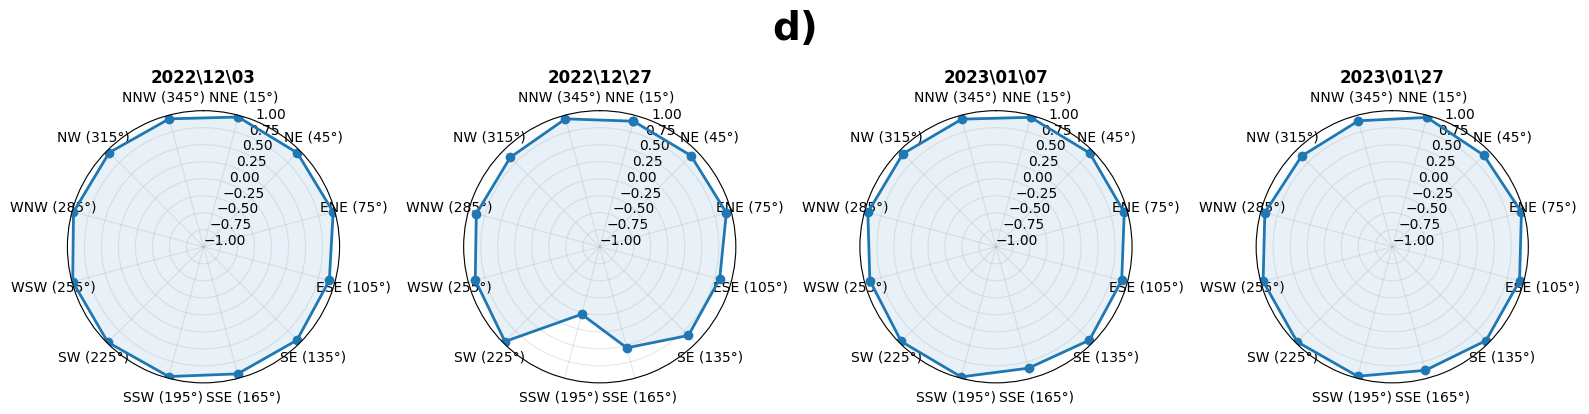

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Get sorted unique dates
dates = sorted(night_metrics_by_date_direction["date"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(dates),
    subplot_kw={'projection': 'polar'},
    figsize=(4 * len(dates), 4)
)

# If only one date, axes is not iterable
if len(dates) == 1:
    axes = [axes]

for ax, date in zip(axes, dates):
    
    df_plot = (
        night_metrics_by_date_direction
        [night_metrics_by_date_direction["date"] == date]
        .sort_values("direction")
    )
    
    theta = np.deg2rad(df_plot["direction"].values)
    values = df_plot["Pearson_r"].values
    
    # Close circle
    theta = np.append(theta, theta[0])
    values = np.append(values, values[0])
    
    ax.plot(theta, values, marker="o", linewidth=2)
    ax.fill(theta, values, alpha=0.1)
    
    # ✅ Geographic orientation
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    
    # ✅ Fixed radial limits
    ax.set_ylim(-1, 1)
    ax.set_yticks(np.arange(-1, 1.01, 0.25))
    
    ax.set_title(pd.Timestamp(date).strftime('%Y\%m\%d'), fontweight='bold')
    
    ax.set_xticks(np.deg2rad(df_plot["direction"]))
    ax.set_xticklabels(
        [direction_labels[d] for d in df_plot["direction"]]
    )
    
    ax.grid(True, alpha=0.3)

plt.suptitle("d)", y=1, fontsize=28, fontweight="bold")
plt.tight_layout()

# --------------------------
# Save figure
# --------------------------
output_path = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\fig10_d_night_polar_Pearson_r.png"
plt.savefig(output_path, dpi=300)
print("Boxplot saved to:", output_path)

plt.show()

# 6. Comparison against air temperature at BOM stations
The LST data for the target dates were compared with air temperature.


## 6.1 LST extraction
First, the fused STARFM outputs were exported to the output folder using filenames such as `d_refer_20230107`, in which the date is encoded as an 8-character string (`YYYYMMDD`) and preceded by an additional 8 characters.

Secondly, for each raster file in the output folder, the LST is extracted using the PWRS and CWS shapefile 
...\shapefile\wn_bom_pt.7z
To do the extraction, the following code was used in ARCGIS [PRWS and CWS LST](preprocessing/pwrs_cws_lst_extraction.txt)

## 6.2 Comparison between LST and Air temperature

In [43]:
import numpy as np
import pandas as pd

# load the extracted LST data
day_lst = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\day_pwrs_cws_lst.csv")
night_lst = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\night_pwrs_cws_lst.csv")
reference_day_lst = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\reference_day_pwrs_cws_lst.csv")
reference_night_lst = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\reference_night_pwrs_cws_lst.csv")

# LST Convert the date column to datetime format
day_lst['date'] = pd.to_datetime(day_lst['date'], format='%d/%m/%Y')
night_lst['date'] = pd.to_datetime(night_lst['date'], format='%d/%m/%Y')
reference_day_lst['date'] = pd.to_datetime(reference_day_lst['date'])
reference_night_lst['date'] = pd.to_datetime(reference_night_lst['date'])

# Add the Time_AEDT column
day_lst['Time_AEDT'] = pd.to_datetime(day_lst['date']) + pd.Timedelta(hours=11)
night_lst['Time_AEDT'] = pd.to_datetime(night_lst['date']) + pd.Timedelta(hours=24)
# Add Time_AEDT (reference)
reference_day_lst['Time_AEDT'] = reference_day_lst['date'] + pd.Timedelta(hours=11)
reference_night_lst['Time_AEDT'] = reference_night_lst['date'] + pd.Timedelta(hours=24)

# Add temporal information to day_lst and night_lst
day_lst['temporal'] = 'day'
night_lst['temporal'] = 'night'

# Temporal info
reference_day_lst['temporal'] = 'day'
reference_night_lst['temporal'] = 'night'

# Keep the date format only day/month/year
day_lst['date'] = day_lst['date'].dt.strftime('%d/%m/%Y')
night_lst['date'] = night_lst['date'].dt.strftime('%d/%m/%Y')
reference_day_lst['date'] = reference_day_lst['date'].dt.strftime('%d/%m/%Y')
reference_night_lst['date'] = reference_night_lst['date'].dt.strftime('%d/%m/%Y')

# Add use information whether reference or target
day_lst['use'] = day_lst['date'].eq('07/01/2023').map({True: 'base', False: 'prediction'})
night_lst['use'] = night_lst['date'].eq('25/12/2022').map({True: 'base', False: 'prediction'})

# Use info
reference_day_lst['use'] = 'reference'
reference_night_lst['use'] = 'reference'


# Merge day_lst with night_lst
day_night_lst = pd.concat([day_lst, night_lst, reference_day_lst, reference_night_lst], ignore_index=True)

# Filter PRWS only
day_night_lst = day_night_lst[day_night_lst['source'] == 'prws']

# save the merged day_night_lst to CSV
out_csv_day_night_lst = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\day_night_lst.csv"
day_night_lst.to_csv(out_csv_day_night_lst, index=False)

# Preview first 40 rows
display(day_night_lst.head(5))

,p_id,source,date,lst_pred,Time_AEDT,temporal,use
267,400,prws,03/12/2022,33.751797,2022-12-03 11:00:00,day,prediction
268,200,prws,03/12/2022,37.289041,2022-12-03 11:00:00,day,prediction
269,600,prws,03/12/2022,37.697760,2022-12-03 11:00:00,day,prediction
270,500,prws,03/12/2022,38.241858,2022-12-03 11:00:00,day,prediction
271,300,prws,03/12/2022,35.678723,2022-12-03 11:00:00,day,prediction


In [44]:
# load the air temperature data with UHI in Chapter 1
air_temp = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\chapter1\output\pwrs_cws_raw.csv")
# Filter PRWS only
air_temp = air_temp[air_temp['data_source'] == 'PRWS']

# load the reference air temperature 
reference_air_temp = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\chapter1\output\reference_pwrs_cws_raw.csv")

# Merge air temperature with reference air temperature
air_temp = pd.concat([air_temp, reference_air_temp], ignore_index=True)

# Keep only relevant columns
air_temp = air_temp[['p_id', 'Time_AEDT', 'Time_UTC', 'ta']]

# save the merged air temperature to CSV
out_csv_air_temp = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\air_temperature.csv"

# Preview first 5 rows
display(air_temp.head(5))

# Export to CSV
air_temp.to_csv(out_csv_air_temp, index=False)

c:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\.venv\lib\site-packages\IPython\core\interactiveshell.py:3553: DtypeWarning: Columns (2) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


,p_id,Time_AEDT,Time_UTC,ta
0,200,2022-12-01 00:00:00,2022-11-30 13:00:00,13.9
1,200,2022-12-01 01:00:00,2022-11-30 14:00:00,12.7
2,200,2022-12-01 02:00:00,2022-11-30 15:00:00,12.1
3,200,2022-12-01 03:00:00,2022-11-30 16:00:00,11.9
4,200,2022-12-01 04:00:00,2022-11-30 17:00:00,12.5


In [45]:
# Convert Time_AEDT to datetime
air_temp['Time_AEDT'] = pd.to_datetime(air_temp['Time_AEDT'], dayfirst=True)
day_night_lst['Time_AEDT'] = pd.to_datetime(day_night_lst['Time_AEDT'], dayfirst=True)

# Merge LST with air temperature data
lst_air_temp = pd.merge(air_temp, day_night_lst, on=['p_id', 'Time_AEDT'], how='inner')

# Order columns
lst_air_temp = lst_air_temp[['temporal', 'use', 'p_id', 'source', 'date', 'Time_AEDT', 'Time_UTC', 'lst_pred', 'ta']]

# Remove duplicates
lst_air_temp = lst_air_temp.drop_duplicates(subset=['p_id', 'Time_AEDT'])

# Keep Predicted LST > 0
lst_air_temp = lst_air_temp[lst_air_temp["lst_pred"] >= 0]

# save the merged lst_air_temp to CSV
out_csv_lst_air_temp = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\lst_air_temp_prws.csv"
lst_air_temp.to_csv(out_csv_lst_air_temp, index=False)

# Preview first 5 rows
display(lst_air_temp.head(5))

# Check the number of rows
num_rows = len(lst_air_temp)
print(f"Number of rows for PRWS only: {num_rows}.")

,temporal,use,p_id,source,date,Time_AEDT,Time_UTC,lst_pred,ta
0,day,prediction,200,prws,03/12/2022,2022-12-03 11:00:00,2022-12-03 00:00:00,37.289041,26.7
1,night,prediction,200,prws,03/12/2022,2022-12-04 00:00:00,2022-12-03 13:00:00,19.704185,20.2
2,night,base,200,prws,25/12/2022,2022-12-26 00:00:00,2022-12-25 13:00:00,18.190001,18.4
3,day,prediction,200,prws,27/12/2022,2022-12-27 11:00:00,2022-12-27 00:00:00,39.431096,32.6
4,night,prediction,200,prws,27/12/2022,2022-12-28 00:00:00,2022-12-27 13:00:00,26.223612,29.3


Number of rows for PRWS only: 69.


**Plot**
To compare the LST with the Air temperature, the equivalent R code can be found [here](preprocessing/R_lst_air_temperature_plot.txt)

Paired t-test: Ttest_relResult(statistic=-23.423632906337986, pvalue=1.4733933257804048e-22)
Paired Wilcoxon test: WilcoxonResult(statistic=0.0, pvalue=2.4770276393652366e-07)


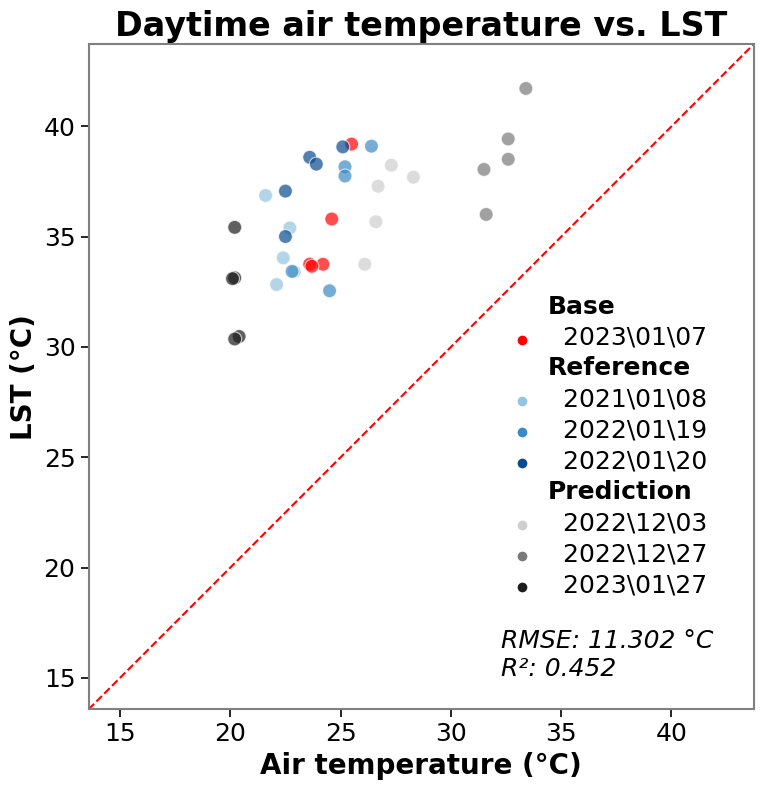

In [ ]:
# Daytime analysis
import pandas as pd
import numpy as np
from scipy import stats
from matplotlib.colors import to_hex
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Filter temporal == 'day'
# -------------------------
lst_air_temp_prws_day = lst_air_temp[lst_air_temp['temporal'] == 'day'].copy()

# -------------------------
# Paired tests
# -------------------------
t_test_result_day = stats.ttest_rel(
    lst_air_temp_prws_day['ta'],
    lst_air_temp_prws_day['lst_pred'],
    nan_policy='omit'
)
print("Paired t-test:", t_test_result_day)

wilcox_result_day = stats.wilcoxon(
    lst_air_temp_prws_day['ta'],
    lst_air_temp_prws_day['lst_pred'],
    zero_method='wilcox',
    alternative='two-sided'
)
print("Paired Wilcoxon test:", wilcox_result_day)

# -------------------------
# R² and RMSE
# -------------------------
r2 = np.corrcoef(
    lst_air_temp_prws_day['ta'],
    lst_air_temp_prws_day['lst_pred']
)[0, 1] ** 2

rmse = np.sqrt(
    np.mean((lst_air_temp_prws_day['ta'] - lst_air_temp_prws_day['lst_pred']) ** 2)
)

info_text = f"RMSE: {rmse:.3f} °C\nR²: {r2:.3f}"

# -------------------------
# Shared scale for comparability
# -------------------------
common_min_val = min(lst_air_temp['ta'].min(), lst_air_temp['lst_pred'].min())
common_max_val = max(lst_air_temp['ta'].max(), lst_air_temp['lst_pred'].max())
axis_padding = 2
axis_min = common_min_val - axis_padding
axis_max = common_max_val + axis_padding
axis_ticks = np.arange(
    np.floor(axis_min / 5) * 5,
    np.ceil(axis_max / 5) * 5 + 1,
    5
)
plot_min = axis_ticks.min()
plot_max = axis_ticks.max()
axis_span = axis_max - axis_min

# -------------------------
# Date handling
# -------------------------
lst_air_temp['date'] = pd.to_datetime(
    lst_air_temp['date'],
    dayfirst=True
)

lst_air_temp_prws_day['date'] = pd.to_datetime(
    lst_air_temp_prws_day['date'],
    dayfirst=True
)

# -------------------------
# Create date_str (used for hue & palette)
# -------------------------
lst_air_temp_prws_day['date_str'] = lst_air_temp_prws_day['date'].dt.strftime('%Y\\%m\\%d')

# -------------------------
# Separate dates by use
# -------------------------
base_dates = lst_air_temp_prws_day.loc[
    lst_air_temp_prws_day['use'] == 'base', 'date_str'
].drop_duplicates()

reference_dates = lst_air_temp_prws_day.loc[
    lst_air_temp_prws_day['use'] == 'reference', 'date_str'
].drop_duplicates()

prediction_dates = lst_air_temp_prws_day.loc[
    lst_air_temp_prws_day['use'] == 'prediction', 'date_str'
].drop_duplicates()

# Sort chronologically
base_dates = sorted(base_dates, key=lambda x: pd.to_datetime(x.replace('\\', '/')))
reference_dates = sorted(reference_dates, key=lambda x: pd.to_datetime(x.replace('\\', '/')))
prediction_dates = sorted(prediction_dates, key=lambda x: pd.to_datetime(x.replace('\\', '/')))

# -------------------------
# Grey gradient for prediction
# -------------------------
pred_cmap = plt.cm.Greys
pred_colors = [
    to_hex(pred_cmap(i))
    for i in np.linspace(0.3, 0.9, len(prediction_dates))
]
prediction_color_map = dict(zip(prediction_dates, pred_colors))

# -------------------------
# Blue gradient for reference
# -------------------------
ref_cmap = plt.cm.Blues
ref_colors = [
    to_hex(ref_cmap(i))
    for i in np.linspace(0.4, 0.9, len(reference_dates))
]
reference_color_map = dict(zip(reference_dates, ref_colors))

# -------------------------
# Full palette
# -------------------------
palette = {}

for _, row in lst_air_temp_prws_day[['date_str', 'use']].drop_duplicates().iterrows():
    
    if row['use'] == 'prediction':
        palette[row['date_str']] = prediction_color_map[row['date_str']]
    
    elif row['use'] == 'reference':
        palette[row['date_str']] = reference_color_map[row['date_str']]
    
    elif row['use'] == 'base':
        palette[row['date_str']] = 'red'



# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(8, 8))

sns.scatterplot(
    data=lst_air_temp_prws_day,
    x='ta',
    y='lst_pred',
    hue='date_str',
    palette=palette,
    s=100,
    alpha=0.7
)

# Identity line
plt.plot(
    [axis_min, axis_max],
    [axis_min, axis_max],
    ls='--',
    color='red'
)

# Annotation
plt.text(
    x=axis_min + 0.62 * axis_span,
    y=axis_min + 0.05 * axis_span,
    s=info_text,
    fontsize=18,
    fontstyle='italic',
    color='black'
)

# Labels
plt.title("Daytime air temperature vs. LST", fontsize=24, fontweight='bold')
plt.xlabel("Air temperature (°C)", fontsize=20, fontweight='bold')
plt.ylabel("LST (°C)", fontsize=20, fontweight='bold')
plt.xticks(axis_ticks, fontsize=18)
plt.yticks(axis_ticks, fontsize=18)

# Axis limits
plt.xlim(axis_min, axis_max)
plt.ylim(axis_min, axis_max)

# -------------------------
# Fully square frame
# -------------------------
ax = plt.gca()
ax.set_aspect('equal')  # square plotting area

# Make all spines visible
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('grey')

# Show ticks on all sides
#ax.xaxis.set_ticks_position('both')
#ax.yaxis.set_ticks_position('both')
ax.tick_params(direction='out', length=6, width=1.2)

# Turn off grid for cleaner look
plt.grid(False)

# -------------------------
# Separate dates by use
# -------------------------
base_dates = lst_air_temp_prws_day.loc[
    lst_air_temp_prws_day['use'] == 'base', 'date_str'
].unique()

reference_dates = lst_air_temp_prws_day.loc[
    lst_air_temp_prws_day['use'] == 'reference', 'date_str'
].unique()

prediction_dates = lst_air_temp_prws_day.loc[
    lst_air_temp_prws_day['use'] == 'prediction', 'date_str'
].unique()

# Sort chronologically
base_dates = sorted(base_dates, key=lambda x: pd.to_datetime(x.replace('\\', '/')))
reference_dates = sorted(reference_dates, key=lambda x: pd.to_datetime(x.replace('\\', '/')))
prediction_dates = sorted(prediction_dates, key=lambda x: pd.to_datetime(x.replace('\\', '/')))

# -------------------------
# Build custom legend
# -------------------------
legend_elements = []

# --- Base section ---
legend_elements.append(Line2D([], [], linestyle='none', label='Base'))

for d in base_dates:
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='red',
               markersize=8,
               label=f'  {d}')
    )

# --- Reference section ---
legend_elements.append(Line2D([], [], linestyle='none', label='Reference'))

for d in reference_dates:
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=reference_color_map[d],
               markersize=8,
               label=f'  {d}')
    )

# --- Prediction section ---
legend_elements.append(Line2D([], [], linestyle='none', label='Prediction'))

for d in prediction_dates:
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=palette[d],
               markersize=8,
               label=f'  {d}')
    )


legend = plt.legend(
    handles=legend_elements,
    #title='Date',
    bbox_to_anchor=(0.95, 0.15),
    loc='lower right',
    frameon=False
)
# Make section headers bold
for text in legend.get_texts():
    text.set_fontsize(18)  # <-- increase overall font size
    if text.get_text().strip() in ['Base', 'Reference', 'Prediction']:
        text.set_fontweight('bold')

# --------------------------
# Save figure
# --------------------------
plt.tight_layout()
plt.savefig(
    "20260201_bom_day_observed_vs_predicted_square_frame.png",
    dpi=300
)
plt.show()

Paired t-test: Ttest_relResult(statistic=0.38214828703792275, pvalue=0.7048014241154024)
Paired Wilcoxon test: WilcoxonResult(statistic=294.0, pvalue=0.9522848171187511)
Boxplot saved to: C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\fig11_b_nighttime_air.png


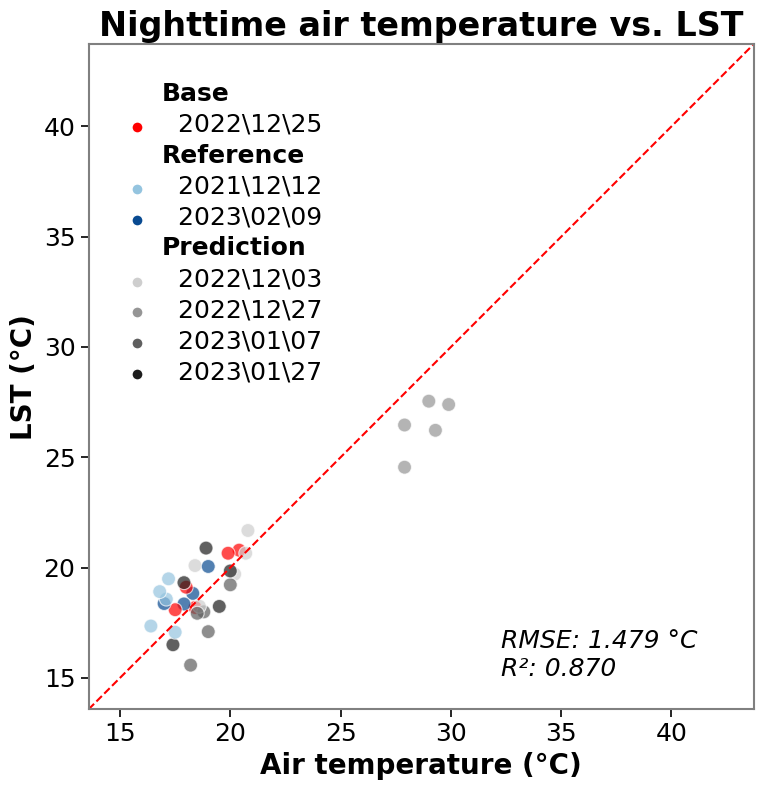

In [103]:
# Nighttime analysis
import pandas as pd
import numpy as np
from scipy import stats
from matplotlib.colors import to_hex
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Filter temporal == 'night'
# -------------------------
lst_air_temp_prws_night = lst_air_temp[lst_air_temp['temporal'] == 'night'].copy()

# -------------------------
# Paired tests
# -------------------------
t_test_result_night = stats.ttest_rel(
    lst_air_temp_prws_night['ta'],
    lst_air_temp_prws_night['lst_pred'],
    nan_policy='omit'
)
print("Paired t-test:", t_test_result_night)

wilcox_result_night = stats.wilcoxon(
    lst_air_temp_prws_night['ta'],
    lst_air_temp_prws_night['lst_pred'],
    zero_method='wilcox',
    alternative='two-sided'
)
print("Paired Wilcoxon test:", wilcox_result_night)

# -------------------------
# R² and RMSE
# -------------------------
r2 = np.corrcoef(
    lst_air_temp_prws_night['ta'],
    lst_air_temp_prws_night['lst_pred']
)[0, 1] ** 2

rmse = np.sqrt(
    np.mean((lst_air_temp_prws_night['ta'] - lst_air_temp_prws_night['lst_pred']) ** 2)
)

info_text = f"RMSE: {rmse:.3f} °C\nR²: {r2:.3f}"

# -------------------------
# Shared scale for comparability
# -------------------------
common_min_val = min(lst_air_temp['ta'].min(), lst_air_temp['lst_pred'].min())
common_max_val = max(lst_air_temp['ta'].max(), lst_air_temp['lst_pred'].max())
axis_padding = 2
axis_min = common_min_val - axis_padding
axis_max = common_max_val + axis_padding
axis_ticks = np.arange(
    np.floor(axis_min / 5) * 5,
    np.ceil(axis_max / 5) * 5 + 1,
    5
)
axis_span = axis_max - axis_min

# -------------------------
# Date handling
# -------------------------
lst_air_temp['date'] = pd.to_datetime(
    lst_air_temp['date'],
    dayfirst=True
)

lst_air_temp_prws_night['date'] = pd.to_datetime(
    lst_air_temp_prws_night['date'],
    dayfirst=True
)

# -------------------------
# Create date_str (used for hue & palette)
# -------------------------
lst_air_temp_prws_night['date_str'] = lst_air_temp_prws_night['date'].dt.strftime('%Y\\%m\\%d')

# -------------------------
# Separate dates by use
# -------------------------
base_dates = lst_air_temp_prws_night.loc[
    lst_air_temp_prws_night['use'] == 'base', 'date_str'
].drop_duplicates()

reference_dates = lst_air_temp_prws_night.loc[
    lst_air_temp_prws_night['use'] == 'reference', 'date_str'
].drop_duplicates()

prediction_dates = lst_air_temp_prws_night.loc[
    lst_air_temp_prws_night['use'] == 'prediction', 'date_str'
].drop_duplicates()

# Sort chronologically
base_dates = sorted(base_dates, key=lambda x: pd.to_datetime(x.replace('\\', '/')))
reference_dates = sorted(reference_dates, key=lambda x: pd.to_datetime(x.replace('\\', '/')))
prediction_dates = sorted(prediction_dates, key=lambda x: pd.to_datetime(x.replace('\\', '/')))

# -------------------------
# Grey gradient for prediction
# -------------------------
pred_cmap = plt.cm.Greys
pred_colors = [
    to_hex(pred_cmap(i))
    for i in np.linspace(0.3, 0.9, len(prediction_dates))
]
prediction_color_map = dict(zip(prediction_dates, pred_colors))

# -------------------------
# Blue gradient for reference
# -------------------------
ref_cmap = plt.cm.Blues
ref_colors = [
    to_hex(ref_cmap(i))
    for i in np.linspace(0.4, 0.9, len(reference_dates))
]
reference_color_map = dict(zip(reference_dates, ref_colors))

# -------------------------
# Full palette
# -------------------------
palette = {}

for _, row in lst_air_temp_prws_night[['date_str', 'use']].drop_duplicates().iterrows():
    
    if row['use'] == 'prediction':
        palette[row['date_str']] = prediction_color_map[row['date_str']]
    
    elif row['use'] == 'reference':
        palette[row['date_str']] = reference_color_map[row['date_str']]
    
    elif row['use'] == 'base':
        palette[row['date_str']] = 'red'


# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(8, 8))

sns.scatterplot(
    data=lst_air_temp_prws_night,
    x='ta',
    y='lst_pred',
    hue='date_str',
    palette=palette,
    s=100,
    alpha=0.7
)

# Identity line
plt.plot(
    [axis_min, axis_max],
    [axis_min, axis_max],
    ls='--',
    color='red'
)

# Annotation
plt.text(
    x=axis_min + 0.62 * axis_span,
    y=axis_min + 0.05 * axis_span,
    s=info_text,
    fontsize=18,
    fontstyle='italic',
    color='black'
)

# Labels
# Labels
plt.title("Nighttime air temperature vs. LST", fontsize=24, fontweight='bold')
plt.xlabel("Air temperature (°C)", fontsize=20, fontweight='bold')
plt.ylabel("LST (°C)", fontsize=20, fontweight='bold')
plt.xticks(axis_ticks, fontsize=18)
plt.yticks(axis_ticks, fontsize=18)

# Axis limits
plt.xlim(axis_min, axis_max)
plt.ylim(axis_min, axis_max)

# -------------------------
# Fully square frame with ticks only on left & bottom
# -------------------------
ax = plt.gca()
ax.set_aspect('equal')  # square plotting area

# Make all spines visible
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('grey')

# Ticks only on left and bottom
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
ax.tick_params(direction='out', length=6, width=1.2)

# Turn off grid for cleaner look
plt.grid(False)

# -------------------------
# Separate dates by use
# -------------------------
base_dates = lst_air_temp_prws_night.loc[
    lst_air_temp_prws_night['use'] == 'base', 'date_str'
].unique()

reference_dates = lst_air_temp_prws_night.loc[
    lst_air_temp_prws_night['use'] == 'reference', 'date_str'
].unique()

prediction_dates = lst_air_temp_prws_night.loc[
    lst_air_temp_prws_night['use'] == 'prediction', 'date_str'
].unique()

# Sort chronologically
base_dates = sorted(base_dates, key=lambda x: pd.to_datetime(x.replace('\\', '/')))
reference_dates = sorted(reference_dates, key=lambda x: pd.to_datetime(x.replace('\\', '/')))
prediction_dates = sorted(prediction_dates, key=lambda x: pd.to_datetime(x.replace('\\', '/')))

# -------------------------
# Build custom legend
# -------------------------
legend_elements = []

# --- Base section ---
legend_elements.append(Line2D([], [], linestyle='none', label='Base'))

for d in base_dates:
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='red',
               markersize=8,
               label=f'  {d}')
    )

# --- Reference section ---
legend_elements.append(Line2D([], [], linestyle='none', label='Reference'))

for d in reference_dates:
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=reference_color_map[d],
               markersize=8,
               label=f'  {d}')
    )

# --- Prediction section ---
legend_elements.append(Line2D([], [], linestyle='none', label='Prediction'))

for d in prediction_dates:
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=palette[d],
               markersize=8,
               label=f'  {d}')
    )


legend = plt.legend(
    handles=legend_elements,
    #title='Date',
    bbox_to_anchor=(0.37, 0.47),
    loc='lower right',
    frameon=False
)
# Make section headers bold
for text in legend.get_texts():
    text.set_fontsize(18)  # <-- increase overall font size
    if text.get_text().strip() in ['Base', 'Reference', 'Prediction']:
        text.set_fontweight('bold')


plt.tight_layout()
# --------------------------
# Save figure
# --------------------------
output_path = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\fig11_b_nighttime_air.png"
plt.savefig(output_path, dpi=300)
print("Boxplot saved to:", output_path)

plt.show()

Boxplot saved to: C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\fig11_all_lst_air.png


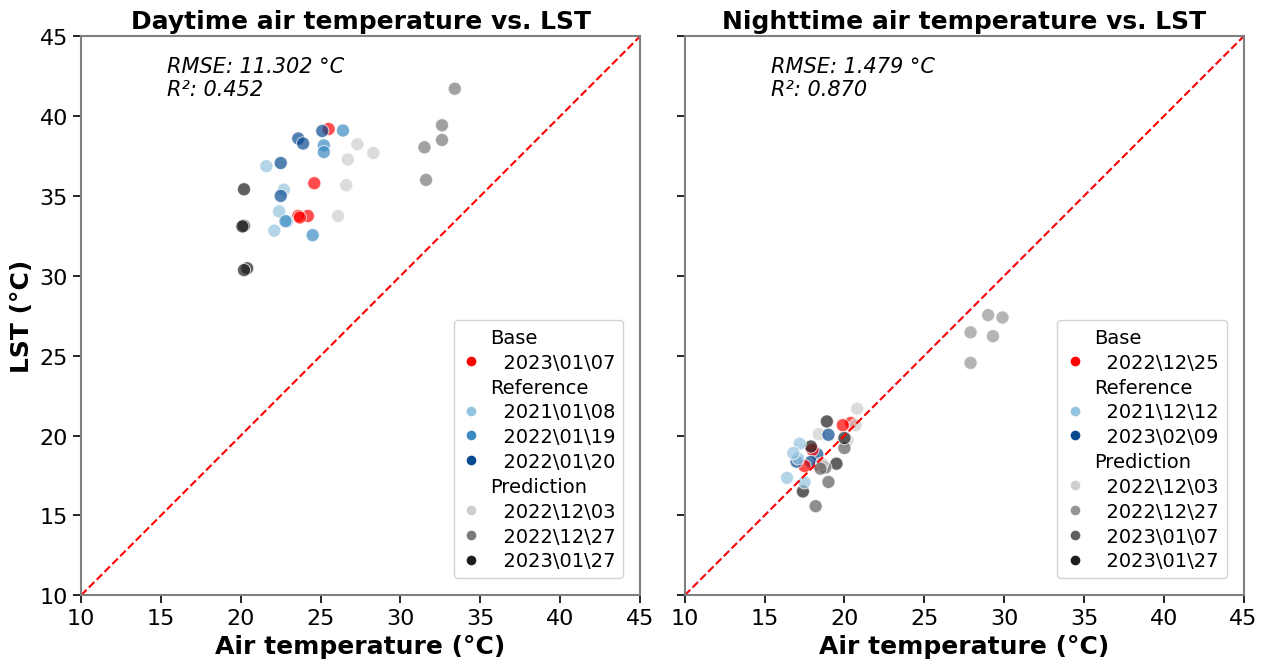

In [121]:
# Day and Night side-by-side comparison
import pandas as pd
import numpy as np
from scipy import stats
from matplotlib.colors import to_hex
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Prepare data
# -------------------------
lst_air_temp_day = lst_air_temp[lst_air_temp['temporal'] == 'day'].copy()
lst_air_temp_night = lst_air_temp[lst_air_temp['temporal'] == 'night'].copy()

lst_air_temp_day['date'] = pd.to_datetime(lst_air_temp_day['date'], dayfirst=True)
lst_air_temp_night['date'] = pd.to_datetime(lst_air_temp_night['date'], dayfirst=True)

lst_air_temp_day['date_str'] = lst_air_temp_day['date'].dt.strftime('%Y\\%m\\%d')
lst_air_temp_night['date_str'] = lst_air_temp_night['date'].dt.strftime('%Y\\%m\\%d')

# Shared scale for direct comparison
common_min_val = min(
    lst_air_temp['ta'].min(),
    lst_air_temp['lst_pred'].min()
)
common_max_val = max(
    lst_air_temp['ta'].max(),
    lst_air_temp['lst_pred'].max()
)
axis_padding = 2
axis_min = common_min_val - axis_padding
axis_max = common_max_val + axis_padding
axis_ticks = np.arange(
    np.floor(axis_min / 5) * 5,
    np.ceil(axis_max / 5) * 5 + 1,
    5
)
plot_min = axis_ticks.min()
plot_max = axis_ticks.max()

# -------------------------
# Stats
# -------------------------
day_ttest = stats.ttest_rel(lst_air_temp_day['ta'], lst_air_temp_day['lst_pred'], nan_policy='omit')
day_wilcoxon = stats.wilcoxon(lst_air_temp_day['ta'], lst_air_temp_day['lst_pred'], zero_method='wilcox', alternative='two-sided')
day_r2 = np.corrcoef(lst_air_temp_day['ta'], lst_air_temp_day['lst_pred'])[0, 1] ** 2
day_rmse = np.sqrt(np.mean((lst_air_temp_day['ta'] - lst_air_temp_day['lst_pred']) ** 2))

ght_ttest = stats.ttest_rel(lst_air_temp_night['ta'], lst_air_temp_night['lst_pred'], nan_policy='omit')
ght_wilcoxon = stats.wilcoxon(lst_air_temp_night['ta'], lst_air_temp_night['lst_pred'], zero_method='wilcox', alternative='two-sided')
ght_r2 = np.corrcoef(lst_air_temp_night['ta'], lst_air_temp_night['lst_pred'])[0, 1] ** 2
ght_rmse = np.sqrt(np.mean((lst_air_temp_night['ta'] - lst_air_temp_night['lst_pred']) ** 2))

# -------------------------
# Date palettes
# -------------------------
def build_palette(df):
    pred_dates = df.loc[df['use'] == 'prediction', 'date_str'].drop_duplicates().tolist()
    ref_dates = df.loc[df['use'] == 'reference', 'date_str'].drop_duplicates().tolist()
    base_dates = df.loc[df['use'] == 'base', 'date_str'].drop_duplicates().tolist()

    pred_dates = sorted(pred_dates, key=lambda x: pd.to_datetime(x.replace('\\', '/')))
    ref_dates = sorted(ref_dates, key=lambda x: pd.to_datetime(x.replace('\\', '/')))
    base_dates = sorted(base_dates, key=lambda x: pd.to_datetime(x.replace('\\', '/')))

    pred_cmap = plt.cm.Greys
    ref_cmap = plt.cm.Blues

    pred_colors = [to_hex(pred_cmap(i)) for i in np.linspace(0.3, 0.9, max(len(pred_dates), 1))]
    ref_colors = [to_hex(ref_cmap(i)) for i in np.linspace(0.4, 0.9, max(len(ref_dates), 1))]

    pred_map = dict(zip(pred_dates, pred_colors))
    ref_map = dict(zip(ref_dates, ref_colors))

    palette = {}
    for _, row in df[['date_str', 'use']].drop_duplicates().iterrows():
        if row['use'] == 'prediction':
            palette[row['date_str']] = pred_map[row['date_str']]
        elif row['use'] == 'reference':
            palette[row['date_str']] = ref_map[row['date_str']]
        elif row['use'] == 'base':
            palette[row['date_str']] = 'red'

    legend_elements = []
    legend_elements.append(Line2D([], [], linestyle='none', label='Base'))
    for d in base_dates:
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label=f'  {d}')
        )
    legend_elements.append(Line2D([], [], linestyle='none', label='Reference'))
    for d in ref_dates:
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor=ref_map[d], markersize=8, label=f'  {d}')
        )
    legend_elements.append(Line2D([], [], linestyle='none', label='Prediction'))
    for d in pred_dates:
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor=pred_map[d], markersize=8, label=f'  {d}')
        )

    return palette, legend_elements

day_palette, day_legend_elements = build_palette(lst_air_temp_day)
night_palette, night_legend_elements = build_palette(lst_air_temp_night)

# -------------------------
# Plot
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0.08, bottom=0.10)

for ax in axes:
    ax.set_aspect('equal')
    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)
    ax.set_xticks(axis_ticks)
    ax.set_yticks(axis_ticks)
    ax.tick_params(direction='out', length=6, width=1.2, labelsize=16)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_color('grey')

sns.scatterplot(
    data=lst_air_temp_day,
    x='ta',
    y='lst_pred',
    hue='date_str',
    palette=day_palette,
    s=90,
    alpha=0.7,
    ax=axes[0],
    legend=False
)
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], ls='--', color='red')
axes[0].set_title('Daytime air temperature vs. LST', fontsize=18, fontweight='bold')
axes[0].set_xlabel('Air temperature (°C)', fontsize=18, fontweight='bold')
axes[0].set_ylabel('LST (°C)', fontsize=18, fontweight='bold')
axes[0].text(
    axis_min + 0.06 * (axis_max - axis_min),
    axis_min + 0.92 * (axis_max - axis_min),
    f'RMSE: {day_rmse:.3f} °C\nR²: {day_r2:.3f}',
    fontsize=15,
    fontstyle='italic'
)
axes[0].legend(
    handles=day_legend_elements,
    loc='lower right',
    bbox_to_anchor=(0.98, 0.02),
    frameon=True,
    framealpha=0.85,
    fontsize=14,
    borderaxespad=0.3,
    labelspacing=0.3,
    handlelength=1.0,
    handletextpad=0.5
)

sns.scatterplot(
    data=lst_air_temp_night,
    x='ta',
    y='lst_pred',
    hue='date_str',
    palette=night_palette,
    s=90,
    alpha=0.7,
    ax=axes[1],
    legend=False
)
axes[1].plot([plot_min, plot_max], [plot_min, plot_max], ls='--', color='red')
axes[1].set_title('Nighttime air temperature vs. LST', fontsize=18, fontweight='bold')
axes[1].set_xlabel('Air temperature (°C)', fontsize=18, fontweight='bold')
axes[1].set_ylabel('LST (°C)', fontsize=18, fontweight='bold')
axes[1].text(
    axis_min + 0.06 * (axis_max - axis_min),
    axis_min + 0.92 * (axis_max - axis_min),
    f'RMSE: {ght_rmse:.3f} °C\nR²: {ght_r2:.3f}',
    fontsize=15,
    fontstyle='italic'
)
axes[1].legend(
    handles=night_legend_elements,
    loc='lower right',
    bbox_to_anchor=(0.98, 0.02),
    frameon=True,
    framealpha=0.85,
    fontsize=14,
    borderaxespad=0.3,
    labelspacing=0.3,
    handlelength=1.0,
    handletextpad=0.5
)

#fig.suptitle('Day vs Night Air Temperature and LST Comparison', fontsize=22, fontweight='bold', y=0.98)
# --------------------------
# Save figure
# --------------------------
output_path = r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\figures\fig11_all_lst_air.png"
plt.savefig(output_path, dpi=300)
print("Boxplot saved to:", output_path)

plt.show()

# 7. Discussion
## Fusion method performances
- Both **STARFM** and **FSDAF** demonstrated strong performance, as shown in the Agreement–Precision–Accuracy (APA) diagram.
- Root Mean Square Error (RMSE) values between fused and reference LST were low for both methods, indicating good overall accuracy.

- SSIM analysis revealed greater variability between fused and reference LST in **FSDAF** compared to **STARFM**.
- When comparing fused products to the base image (where no reference image was available):
  - SSIM values were consistently higher for **STARFM**.
  - This indicates that STARFM better preserves the spatial structure and thermal patterns of the original LST.

- Although **FSDAF** is specifically designed for heterogeneous landscapes (Zhu et al., 2016; 2018), it was outperformed in this study by the improved Python implementation of **STARFM** (Mileva et al., 2018).
  
- The improved STARFM version:
  - Uses a weighting function based on both **spectral similarity** and **spatial proximity**.
  - Captures subtle local variability.
  - Accounts for the distance between neighboring pixels and the prediction pixel.
  
- The original STARFM (Gao et al., 2006):
  - Used a weighting function based solely on spectral similarity.
  - Considered only spectrally similar pixels (same spectral class) for information transfer.

- In contrast, FSDAF:
  - Relies on land cover classification (Random Forest in this study).
  - Is less sensitive to intra-class variability.
  - Uses classified land cover information rather than direct spectral similarity.
  - The use of direct LST instead of spectral bands further limited its ability to reproduce fine-scale spatial patterns.

## Limitations of the Directional Profiling Approach
### 1. Assumption of Comparable Environmental Conditions
- The method assumes that anisotropic factors (e.g., soil moisture, solar geometry) are comparable between base and prediction dates.
- In reality, these factors vary seasonally and synoptically.
- Such variability may partially explain differences observed in ΔT profiles.
- For example:
  - Deviations in the **SSW and SSE** directions were linked to transitions between contrasting land-cover types.
  - Variations over grassland areas may reflect seasonal differences in moisture conditions, particularly between early and mid-summer.

### 2. Scale Effect of Increasing Buffer Area
- ΔT was calculated using the **mean LST within each buffer**.
- Buffer area increases with radial distance.
- Outer rings therefore incorporate greater spatial heterogeneity.
- This may increase variability in mean temperature estimates.
- The scale effect can influence interpretation of thermal gradients toward the image edges.

### 3. Directional Configuration Sensitivity
- The 12 directions (30° intervals) were derived by dividing the circle into four sectors and subdividing each into three equal parts.
- While this configuration captures major land-cover transitions:
  - The magnitude and shape of ΔT gradients may vary if different directional intervals are used.
- Therefore, results may be partially sensitive to directional resolution.


## Daytime vs Nighttime Fusion Performance

### Daytime Fusion Performance

- Daytime fused LST showed higher accuracy than nighttime 

- This is likely because daytime LST is influenced by multiple spatially heterogeneous factors, including:
  - Vegetation evapotranspiration cooling (Zhao et al., 2014),
  - Building thermal inertia,
  - Incoming solar radiation.
-->
  - Local thermal contrasts are better preserved.
  - LST gradients are more clearly reproduced.
  - SSIM values are higher during daytime.

---

### Nighttime Fusion Performance

- Nighttime LST is primarily influenced by:
  - Anthropogenic heat release,
  - Daytime heat storage (Chakraborty & Lee, 2019; Lin et al., 2024).

- These processes:
  - Vary between dates,
  - Reduce spatial thermal contrast,
  - Lower LST–LST correlation between fused and reference images.

---

## Relationship with Near-Surface Air Temperature

- Nighttime LST exhibited stronger agreement with near-surface air temperature.
- The difference between LST and air temperature was smaller at night than during the day.

- Previous studies comparing MODIS-derived LST with near-surface air temperature report:
  - Statistically significant relationships,
  - Stronger correlations during nighttime,
  - More stable atmospheric conditions at night.



# 7. References
- Ermida, S. L., Soares, P., Mantas, V., Göttsche, F.-M., & Trigo, I. F. (2020). Google earth engine open-source code for land surface temperature estimation from the landsat series. Remote Sensing, 12(9), 1471. 
- Gao, F., Masek, J., Schwaller, M., & Hall, F. (2006). On the blending of the Landsat and MODIS surface reflectance: Predicting daily Landsat surface reflectance. IEEE Transactions on Geoscience and Remote sensing, 44(8), 2207-2218.
- Mileva, N., Mecklenburg, S., & Gascon, F. (2018). New tool for spatio-temporal image fusion in remote sensing: A case study approach using Sentinel-2 and Sentinel-3 data. Image and Signal Processing for Remote Sensing Xxiv
- Zhu, X., Helmer, E. H., Gao, F., Liu, D., Chen, J., & Lefsky, M. A. (2016). A flexible spatiotemporal method for fusing satellite images with different resolutions. Remote Sensing of Environment, 172, 165-177. https://doi.org/https://doi.org/10.1016/j.rse.2015.11.016 
- Zhu, X., Zhan, W., Zhou, J., Chen, X., Liang, Z., Xu. S., Chen, J.2022. A novel framework to assess all-round performances of spatiotemporal fusion models, Remote Sensing of Environment，274，113002，https://doi.org/10.1016/j.rse.2022.113002 
- Yang, Q., Ye, R., Chakraborty, T. C., Hu, T., & Liu, Y. (2026). Estimation of intensity, footprint, and capacity of surface urban heat islands using a direction-enhanced adaptive synchronous extraction (DEASE) method. Remote Sensing of Environment, 333, 115118.
